# Bulk method (refactored structure)

This notebook is a structural and visualization refactor of `Bulk_method.ipynb`.

Refactor goals:
- keep scientific calculations, model loading behavior, and variable conventions unchanged
- improve sectioning and readability
- improve plotting consistency through shared visualization settings


## 1. Setup


In [ ]:
import matplotlib.pyplot as plt

# Consistent plotting style for readability (does not change scientific calculations)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
})


def apply_standard_labels(ax, title=None, xlabel=None, ylabel=None):
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    return ax


# pre

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import xesmf as xe
import intake
# import psyplot.project as psy
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import pearsonr, linregress
import seaborn as sns
import gsw
import sys
import os
import cmocean.cm as cm
sys.path.append('/g/data/jk72/zc0441')
# sys.path.append('/g/data/jk72/zc0441/zpackage/EXTRA_PYTHON_LIBS/lib/python3.10/site-packages/')
# sys.path.append('/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.04/lib/python3.10/site-packages/')

from zpackage import wmt
from zpackage.ztake import *
# from zpackage.zclef_v2 import *

In [3]:
# cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")
cmip6 = intake.cat.access_nri['cmip6_oi10']

cmip6_fs38 = intake.cat.access_nri['cmip6_fs38']

In [4]:
base_data_dir = '/g/data/jk72/zc0441/Subject_3/data/'
base_data_dir_2 = '/g/data/jk72/zc0441/Subject_2/data/'
time_range = slice('1979','2014')
model_list =[
 'ACCESS-ESM1-5',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CNRM-ESM2-1',
 'IPSL-CM6A-LR',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-MM',
 'UKESM1-0-LL']
model_list_1 = [
 'IPSL-CM6A-LR',   
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'UKESM1-0-LL',
 'NorESM2-MM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'CNRM-ESM2-1',
]
model_list_dissic = ['ACCESS-ESM1-5',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 # 'CNRM-ESM2-1',
 'IPSL-CM6A-LR',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-MM',
 # 'UKESM1-0-LL'
]

## 2. Data loading (ztake workflows)


## functions

In [5]:
def smooth_along_density(da, win=5, center=True, min_periods=1):
    """
    Smooth a DataArray along the 'density' dimension using a rolling mean.
    Works for (block, density) or (time/block/year, density).
    """
    return da.rolling(density=win, center=center, min_periods=min_periods).mean()

In [6]:
def decadal_block_monthly_mean(da):
    years = da['time'].dt.year
    block = ((years - years.min()) // 10).astype('int32')
    block = block.rename('block')  # 给它一个名字

    da = da.assign_coords({'block': block})

    out = da.groupby('block').map(
        lambda x: x.groupby('time.month').mean('time')
    )
    return out


In [7]:
def get_i_j_dim(da):
    """
    Return the two horizontal dims (i, j–like) as separate values.
    Works for i/j, x/y, nlat/nlon, etc.
    """
    exclude = {
        "time", "year", "month",
        "lev", "depth", "z", "sigma", "rho", "density", "olevel"
    }
    spatial = [d for d in da.dims if d not in exclude]

    if len(spatial) != 2:
        raise ValueError(f"Expected 2 horizontal dims, got {spatial}")

    return spatial[0], spatial[1]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_wmt_blocks_colored_by_year(
    wmt_block,
    block_dim="block",
    density_dim="density",
    block_years=None,
    start_year=None,
    cmap="viridis",
    ax=None,
    lw=1.8,
    alpha=0.9,
):
    """
    Plot WMT(density) for all blocks; line color encodes block start-year.

    Parameters
    ----------
    wmt_block : xr.DataArray
        dims: (block_dim, density_dim)
    block_years : int, optional
        Length of each block in years. If None, try wmt_block.attrs['block_years'].
    start_year : int, optional
        Start year of first block. If None, try wmt_block.attrs['start_year'].
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 4.5))
    else:
        fig = ax.figure

    # --- get block coordinate values ---
    bvals = wmt_block[block_dim].values

    # Case 1: block coordinate already looks like years (e.g., 1850, 1860, ...)
    # Heuristic: if values are >= 1000 and integer-like, treat as years
    if np.issubdtype(bvals.dtype, np.number) and np.nanmin(bvals) >= 1000:
        years = bvals.astype(int)
    else:
        # Case 2: block is 0,1,2,... -> infer years from attrs or user inputs
        if block_years is None:
            block_years = wmt_block.attrs.get("block_years", 10)
        if start_year is None:
            start_year = wmt_block.attrs.get("start_year", None)
        if start_year is None:
            raise ValueError(
                "Cannot infer block years. Provide start_year=... (and optionally block_years=...)."
            )
        years = (start_year + bvals.astype(int) * int(block_years)).astype(int)

    # --- colormap normalization ---
    norm = mpl.colors.Normalize(vmin=years.min(), vmax=years.max())
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    dens = wmt_block[density_dim].values

    # --- plot each block as one line ---
    for bi, yr in zip(bvals, years):
        y = wmt_block.sel({block_dim: bi}).values
        ax.plot(dens, y, color=sm.to_rgba(yr), lw=lw, alpha=alpha)

    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_xlabel(f"{density_dim}")
    ax.set_ylabel("WMT")
    ax.set_title("WMT by block (lines colored by block start year)")

    # colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Block start year")

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


In [9]:
def tr_to_fr(transformation_rate):
    """
    Convert transformation rate to formation rate for 1D and 2D arrays.
    """
    # Ensure the input is a DataArray
    if not isinstance(transformation_rate, xr.DataArray):
        raise ValueError("Input must be an xarray DataArray")
    
    # Initialize formation rate array with the same shape as the transformation rate array
    fr = xr.zeros_like(transformation_rate)
    
    # Handle 1D case
    if transformation_rate.ndim == 1:
        for index, value in enumerate(transformation_rate):
            value = value.item()  # Get the value from the DataArray
            if value > 0:
                # index_2 = index + 1
                fr[index] += abs(value)
                fr[index-1] -= abs(value)
            else:
                # index_2 = index - 1
                fr[index-1] += abs(value)
                fr[index] -= abs(value)
            # fr[index] -= abs(value)
            # if index_2 >= 0 and index_2 < len(fr):
            #     fr[index_2] += abs(value)
    
    # Handle 2D case
    elif transformation_rate.ndim == 2:
        for i in range(transformation_rate.shape[0]):
            for j in range(transformation_rate.shape[1]):
                value = transformation_rate[i, j].item()
                if value > 0:
                    # index_2 = j + 1
                    fr[i,j] += abs(value)
                    fr[i,j-1] -= abs(value)
                else:
                    fr[i,j-1] += abs(value)
                    fr[i,j] -= abs(value)
                    # index_2 = j - 1

                # fr[i, j] -= abs(value)

                # if index_2 >= 0 and index_2 < transformation_rate.shape[1]:
                #     fr[i, index_2] += abs(value)
    
    else:
        raise ValueError("Input must be a 1D or 2D xarray DataArray")
    
    return fr

In [10]:
def detrend_along_dim(da, dim):
    """
    Remove a linear trend from a DataArray along a given dimension.

    Parameters
    ----------
    da : xr.DataArray
        Input data.
    dim : str
        Dimension along which to detrend (e.g., "block", "year", "time").

    Returns
    -------
    da_detrended : xr.DataArray
        Detrended data.
    trend : xr.DataArray
        The fitted linear trend.
    """
    coef = da.polyfit(dim=dim, deg=1)
    trend = xr.polyval(da[dim], coef.polyfit_coefficients)
    da_detrended = da - trend
    return da_detrended, trend


In [11]:
def calculate_wmt_from_blocked(
    data_dict,
    model,
    variable_name="sidd_weighted_monthly",
    density_min=1024,
    density_max=1029,
    step=0.1,
    unit="Sv",
    v_type="sea ice",
    block_dim="block",
    time_dim=None,          # 若 None：自动在 ['month','time'] 里找
):
    """
    Input fields are already blocked by decade (have block_dim).
    Compute WMT(density) for each block.

    Expected dims (typical):
      - sidd_data:   (block, month, j, i) or (block, time, j, i)
      - density/tos/sos: same dims as sidd_data

    Returns: xr.DataArray with dims (block, density)
    """

    # ---------- pull data ----------
    sidd_data = data_dict[model][variable_name]
    density_data = data_dict[model]["density_monthly"]
    temperature_data = data_dict[model]["tos_monthly"]
    salinity_data = data_dict[model]["sos_monthly"]

    # ---------- unit ----------
    if unit == "Pg":
        Pg = 1e12
        sidd_data_in_unit = sidd_data / Pg * 365.25 * 24 * 360
    else:
        Sv = 1e6
        sidd_data_in_unit = sidd_data / Sv

    # ---------- find time-like dim ----------
    if time_dim is None:
        if "month" in sidd_data_in_unit.dims:
            time_dim = "month"
        elif "time" in sidd_data_in_unit.dims:
            time_dim = "time"
        else:
            raise ValueError(f"Cannot infer time dimension from {sidd_data_in_unit.dims}. "
                             f"Pass time_dim explicitly (e.g., 'month' or 'time').")

    # ---------- lat mask ----------
    lat_coord, lon_coord = get_lat_lon_coords(sidd_data_in_unit)
    sidd_data_in_unit = sidd_data_in_unit.where(sidd_data_in_unit[lat_coord] < -45)

    # ---------- model-specific fixes (same logic as yours; assumes dims align) ----------
    if "CMCC" in model:
        density_data = density_data[..., :-1, 1:-1]
        temperature_data = temperature_data[..., :-1, 1:-1]
        salinity_data = salinity_data[..., :-1, 1:-1]

    if "NorESM" in model and "sid" in variable_name:
        density_data = density_data[..., :-1, :]
        temperature_data = temperature_data[..., :-1, :]
        salinity_data = salinity_data[..., :-1, :]

    if "FGOALS" in model:
        density_data = density_data.isel(j=slice(None, None, -1))
        temperature_data = temperature_data.isel(j=slice(None, None, -1))
        salinity_data = salinity_data.isel(j=slice(None, None, -1))

    if "CAS-ESM" in model:
        sidd_data_in_unit = sidd_data_in_unit.roll({sidd_data_in_unit.dims[-1]: 1}, roll_coords=True)

    # ---------- basic checks ----------
    for arr, name in [(density_data, "density_data"), (temperature_data, "tos"), (salinity_data, "sos")]:
        if block_dim not in arr.dims:
            raise ValueError(f"{name} missing block dim '{block_dim}'. dims={arr.dims}")
    if block_dim not in sidd_data_in_unit.dims:
        raise ValueError(f"sidd missing block dim '{block_dim}'. dims={sidd_data_in_unit.dims}")

    # ---------- helper: compute WMT(density) for one block slice ----------
    def _calc_one_block(sidd_sl, dens_sl, temp_sl, sal_sl):
        # buoyancy transform rate
        if v_type == "water":
            buoy_rate = wmt.trans_rate_water(sidd_sl, sal_sl, temp_sl, p=0)
        elif v_type == "heat":
            buoy_rate = wmt.trans_rate_heat(sidd_sl, sal_sl, temp_sl, p=0)
        elif v_type == "sea ice":
            if ("CAS-ESM" in model) or ("CESM2" in model) or ("CIESM" in model):
                buoy_values = wmt.trans_rate_seaice(
                    sidd_sl.values, sal_sl.values, temp_sl.values, p=0
                )
                buoy_rate = xr.DataArray(buoy_values, dims=sidd_sl.dims, coords=sidd_sl.coords)
            else:
                buoy_rate = wmt.trans_rate_seaice(sidd_sl, sal_sl, temp_sl, p=0)
        else:
            buoy_rate = sidd_sl

        wmt_rate = -buoy_rate / step

        density_centers = np.arange(density_min, density_max, step)
        out = []

        ntime = wmt_rate.sizes.get(time_dim, None)
        if ntime is None:
            raise ValueError(f"Expected time_dim '{time_dim}' in wmt_rate.dims={wmt_rate.dims}")

        for center in density_centers:
            lower = center - step / 2
            upper = center + step / 2
            mask = (dens_sl >= lower) & (dens_sl < upper)

            if ("CAS-ESM" in model) or ("CESM2" in model) or ("CIESM" in model):
                acc = wmt_rate.where(mask.values).sum()
            else:
                acc = wmt_rate.where(mask).sum()

            # 输入已十年化：这里做“该 block 内月平均”
            out.append(acc / ntime)

        return xr.DataArray(out, coords={"density": density_centers}, dims=["density"])

    # ---------- loop blocks ----------
    block_vals = sidd_data_in_unit[block_dim].values
    results = []

    for b in block_vals:
        sidd_sl = sidd_data_in_unit.sel({block_dim: b})
        dens_sl = density_data.sel({block_dim: b})
        temp_sl = temperature_data.sel({block_dim: b})
        sal_sl  = salinity_data.sel({block_dim: b})

        results.append(_calc_one_block(sidd_sl, dens_sl, temp_sl, sal_sl))

    out = xr.concat(results, dim=xr.IndexVariable(block_dim, block_vals))
    out.attrs["note"] = f"Computed per {block_dim}; normalized by n({time_dim}) within each block."
    return out


# ztake

## fgco2

In [12]:
constraints = dict(
    experiment_id="historical",
    variable_id="fgco2",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_fgco2_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_fgco2_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## spco2

In [13]:
constraints = dict(
    experiment_id="historical",
    variable_id="spco2",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_spco2_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_spco2_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## dissic

In [14]:
constraints = dict(
    experiment_id="historical",
    variable_id="dissic",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_dissic_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_dissic_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## wfo

In [15]:
constraints = dict(
    experiment_id="historical",
    variable_id="wfo",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_wfo_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_wfo_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [16]:
constraints = dict(
    experiment_id="piControl",
    variable_id="wfo",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_wfo_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_wfo_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [17]:
# zt_wfo_pi._best_df

In [18]:
constraints = dict(
    experiment_id="historical",
    variable_id="vsf",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_vsf_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

# zt_vsf_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
#            prefer_members=("r1i1p1f1","r1i1p1f2"),
#            prefer_grids=("gn","gr","gr1")
#           )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [19]:
# vsf_ds

## hfds

In [20]:
constraints = dict(
    experiment_id="historical",
    variable_id="hfds",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_hfds_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_hfds_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [21]:
constraints = dict(
    experiment_id="piControl",
    variable_id="hfds",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_hfds_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_hfds_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## sos

In [22]:
constraints = dict(
    experiment_id="historical",
    variable_id="sos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_sos_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_sos_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [23]:
constraints = dict(
    experiment_id="piControl",
    variable_id="sos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_sos_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_sos_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [24]:
# zt_sos_pi._best_df

## tos

In [25]:
constraints = dict(
    experiment_id="historical",
    variable_id="tos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_tos_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_tos_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [26]:
constraints = dict(
    experiment_id="piControl",
    variable_id="tos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_tos_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )
zt_tos_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## areacello

In [27]:
constraints = dict(
    experiment_id="historical",
    variable_id="areacello",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_areacello_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_areacello_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


## 3. Preprocessing (multi-model)


# Process(multi-model)

In [18]:
model = 'CESM2'
fgco2 = zt_fgco2_hist.open_model(model)['fgco2']
# tos = zt_tos_hist.open_model(model)['tos']
# sos = zt_sos_hist.open_model(model)['sos']
# dissic = zt_dissic_hist.open_model(model)['dissic']
# if 'CESM' in model:
#     fn = f"{base_data_dir}{model}/vsf_historical_{model}.nc"
#     wfo = xr.open_dataset(fn)
# else:
#     wfo = zt_wfo_hist.open_model(model)['wfo']
# hfds = zt_hfds_hist.open_model(model)['hfds']
# density = gsw.rho(sos, tos, 0).compute()

fn = f"/g/data/jk72/zc0441/Subject_2/data/{model}/areacello_historical_gn.nc"
areacello = xr.open_dataset(fn)['areacello']

lat_coord, lon_coord = get_lat_lon_coords(fgco2)
i_dim, j_dim = get_i_j_dim(fgco2)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'fgco2' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [47]:
base_data_dir

'/g/data/jk72/zc0441/Subject_3/data/'

## 4. Analysis


## fgco timeseries 

### calcualtion and save

In [50]:
outdir = base_data_dir

for model in model_list:
    print(f"Processing {model}")

    # --- load ---
    if 'ACCESS' in model:
        fgco2 = zt_fgco2_hist_fs38.open_model(model)["fgco2"]
    else:
        fgco2 = zt_fgco2_hist.open_model(model)["fgco2"]

    fn = f"/g/data/jk72/zc0441/Subject_2/data/{model}/areacello_historical_gn.nc"
    areacello = xr.open_dataset(fn)["areacello"]

    lat_coord, lon_coord = get_lat_lon_coords(fgco2)

    # --- area-weighted flux ---
    fgco2_area = fgco2 * areacello

    # restore lat/lon if dropped
    if (lat_coord not in fgco2_area.coords) or (lon_coord not in fgco2_area.coords):
        fgco2_area = fgco2_area.assign_coords(
            {
                lat_coord: fgco2[lat_coord],
                lon_coord: fgco2[lon_coord],
            }
        )

    # infer horizontal dims *after* fgco2_area exists
    i_dim, j_dim = get_i_j_dim(fgco2_area)

    # --- diagnostics ---
    fgco2_area_mean_by_year = (
        fgco2_area
        .where(fgco2_area[lat_coord] < -45)
        .groupby("time.year")
        .mean("time")
        .mean(dim=[i_dim, j_dim])
        .compute()
    )

    fgco2_area_sum_by_year = (
        fgco2_area
        .where(fgco2_area[lat_coord] < -45)
        .groupby("time.year")
        .mean("time")
        .sum(dim=[i_dim, j_dim])
        .compute()
    )

    # --- save ---
    ds_out = xr.Dataset(
        {
            "fgco2_area_mean_by_year": fgco2_area_mean_by_year,
            "fgco2_area_sum_by_year": fgco2_area_sum_by_year,
        }
    )

    out_fn = f"{outdir}{model}/fgco2_south45_annual_1850_2014_hist.nc"
    ds_out.to_netcdf(out_fn)

    print(f"Saved: {out_fn}")


Processing ACCESS-ESM1-5
Saved: /g/data/jk72/zc0441/Subject_3/data/ACCESS-ESM1-5/fgco2_south45_annual_1850_2014_hist.nc
Processing CESM2
Saved: /g/data/jk72/zc0441/Subject_3/data/CESM2/fgco2_south45_annual_1850_2014_hist.nc
Processing CESM2-FV2
Saved: /g/data/jk72/zc0441/Subject_3/data/CESM2-FV2/fgco2_south45_annual_1850_2014_hist.nc
Processing CESM2-WACCM
Saved: /g/data/jk72/zc0441/Subject_3/data/CESM2-WACCM/fgco2_south45_annual_1850_2014_hist.nc
Processing CESM2-WACCM-FV2
Saved: /g/data/jk72/zc0441/Subject_3/data/CESM2-WACCM-FV2/fgco2_south45_annual_1850_2014_hist.nc
Processing CNRM-ESM2-1
Saved: /g/data/jk72/zc0441/Subject_3/data/CNRM-ESM2-1/fgco2_south45_annual_1850_2014_hist.nc
Processing IPSL-CM6A-LR
Saved: /g/data/jk72/zc0441/Subject_3/data/IPSL-CM6A-LR/fgco2_south45_annual_1850_2014_hist.nc
Processing MPI-ESM1-2-HR
Saved: /g/data/jk72/zc0441/Subject_3/data/MPI-ESM1-2-HR/fgco2_south45_annual_1850_2014_hist.nc
Processing MPI-ESM1-2-LR
Saved: /g/data/jk72/zc0441/Subject_3/data/MPI

## 5. Visualization


### plot

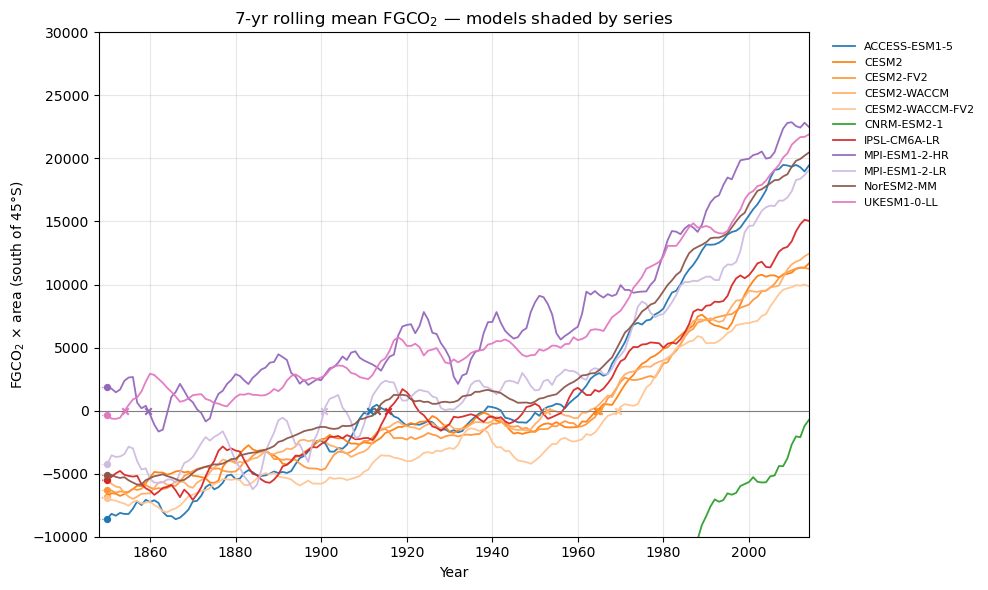

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

indir = "/g/data/jk72/zc0441/Subject_3/data"
win = 7

def get_flip_year_from_smoothed(sm):
    y = sm.values
    yrs = sm["year"].values
    valid = np.isfinite(y)
    y_v = y[valid]
    yrs_v = yrs[valid]
    if len(y_v) < 2:
        return None
    sc = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]
    if len(sc) == 0:
        return None
    k = sc[0]
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    return x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

def blend_with_white(rgb, t):
    """t=0 -> original color, t=1 -> white"""
    r, g, b = rgb
    return (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)

# --- group models by series ---
model_series = {}
for model in model_list:
    series = model.split("-")[0]
    model_series.setdefault(series, []).append(model)

# --- base color per series (tab10 cycles automatically) ---
series_names = sorted(model_series.keys())
base_colors = plt.cm.tab10.colors
series_color = {s: base_colors[i % len(base_colors)] for i, s in enumerate(series_names)}

# --- assign a distinct shade to each model within its series ---
model_color = {}
for s in series_names:
    ms = sorted(model_series[s])
    if len(ms) == 1:
        model_color[ms[0]] = series_color[s]
    else:
        # lightness ramp within series: small spread so they look "similar"
        ts = np.linspace(0.0, 0.55, len(ms))  # 0=base, 0.55=lighter
        for m, t in zip(ms, ts):
            model_color[m] = blend_with_white(series_color[s], t)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 6))

for model in model_list:
    fn = f"{indir}/{model}/fgco2_south45_annual_1850_2014_hist.nc"
    ds = xr.open_dataset(fn)

    ts = ds["fgco2_area_sum_by_year"]
    sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

    c = model_color[model]

    # line
    ax.plot(sm["year"], sm.values, lw=1.3, alpha=0.95, color=c, label=model)

    # start point + horizontal guide
    y = sm.values
    yrs = sm["year"].values
    valid = np.isfinite(y)
    if valid.any():
        i0 = np.where(valid)[0][0]
        x_start = yrs[i0]
        y_start = y[i0]

        ax.scatter([x_start], [y_start], s=18, marker="o", color=c, zorder=5)

        ax.hlines(
            y_start,
            xmin=ax.get_xlim()[0],
            xmax=x_start,
            colors=c,
            linestyles=":",
            linewidth=0.9,
            alpha=0.8,
        )

    # flip year + vertical guide
    flip_year = get_flip_year_from_smoothed(sm)
    if flip_year is not None:
        ax.scatter([flip_year], [0], s=22, marker="x", color=c, zorder=6)

        # ax.vlines(
        #     flip_year,
        #     ymin=ax.get_ylim()[0],
        #     ymax=0,
        #     colors=c,
        #     linestyles="--",
        #     linewidth=0.9,
        #     alpha=0.8,
        # )

ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("FGCO$_2$ × area (south of 45°S)")
ax.set_title(f"{win}-yr rolling mean FGCO$_2$ — models shaded by series")
ax.grid(True, alpha=0.3)
ax.set_xlim(1848, 2014)
ax.set_ylim(-1e4, 3e4)


# legend: all models, but grouped by color family visually
ax.legend(frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()


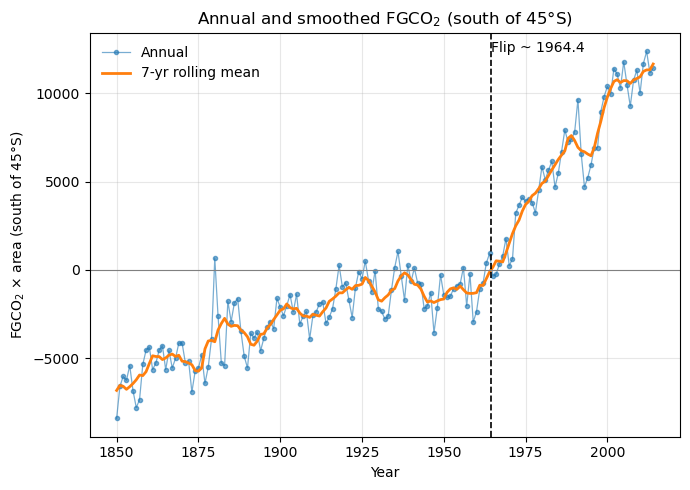

Flip year (zero crossing of smoothed series): 1964.4124545583147


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# --- ensure 1D series on 'year' ---
ts = fgco2_area_sum_by_year

# --- smoothing window (years). Choose 5, 7, 9, 11 depending on how smooth you want it ---
win = 7

# centered rolling mean; min_periods avoids dropping the ends too aggressively
sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

# --- find flip point: first year where smoothed series crosses 0 ---
y = sm.values
yrs = sm["year"].values

valid = np.isfinite(y)
yrs_v = yrs[valid]
y_v = y[valid]

# sign-change indices between consecutive points
sign_change = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]

flip_year = None
if len(sign_change) > 0:
    k = sign_change[0]
    # linear interpolation for a more precise crossing year
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    flip_year = x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ts["year"], ts.values, marker="o", ms=3, lw=0.9, alpha=0.6, label="Annual")
ax.plot(sm["year"], sm.values, lw=2.0, label=f"{win}-yr rolling mean")
ax.axhline(0, color="0.5", lw=0.8)

if flip_year is not None:
    ax.axvline(flip_year, color="k", lw=1.2, ls="--")
    ax.text(
        flip_year, 0.98, f"Flip ~ {flip_year:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top"
    )

ax.set_xlabel("Year")
ax.set_ylabel("FGCO$_2$ × area (south of 45°S)")
ax.set_title("Annual and smoothed FGCO$_2$ (south of 45°S)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Flip year (zero crossing of smoothed series):", flip_year)


## DIC bias

### Calculation and save

In [22]:

# zt_dissic_hist_fs38.open_model(model)["dissic"]

In [19]:
model_list[5:]

['CNRM-ESM2-1',
 'IPSL-CM6A-LR',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-MM',
 'UKESM1-0-LL']

In [23]:
outdir = base_data_dir

for model in model_list[6:]:
    print(f"Processing {model}")

    # --- load dissic ---
    if "ACCESS" in model:
        dissic = zt_dissic_hist_fs38.open_model(model)["dissic"]
    else:
        dissic = zt_dissic_hist.open_model(model)["dissic"]

    fn = f"/g/data/jk72/zc0441/Subject_2/data/{model}/areacello_historical_gn.nc"
    areacello = xr.open_dataset(fn)["areacello"]

    lat_coord, lon_coord = get_lat_lon_coords(dissic)

    # --- align areacello to dissic grid/dims (important) ---
    # This assumes areacello is already on the same i/j grid; otherwise you must remap.
    i_dim, j_dim = get_i_j_dim(dissic)

    # broadcast area to dissic dims (so weighting works with lev/time present)
    area = areacello
    if (lat_coord not in area.coords) and (lat_coord in dissic.coords):
        area = area.assign_coords({lat_coord: dissic[lat_coord]})
    if (lon_coord not in area.coords) and (lon_coord in dissic.coords):
        area = area.assign_coords({lon_coord: dissic[lon_coord]})

    # --- region mask south of 45S ---
    mask = dissic[lat_coord] < -45
    dissic_s = dissic.where(mask)
    area_s = area.where(mask)

    # --- annual mean first (time -> year) ---
    dissic_ann = dissic_s.groupby("time.year").mean("time")

    # --- area-weighted mean (sum(dissic*area)/sum(area)) ---
    numer = (dissic_ann * area_s).sum(dim=[i_dim, j_dim], skipna=True)
    denom = area_s.sum(dim=[i_dim, j_dim], skipna=True)
    dissic_aw_mean_by_year = (numer / denom).compute()

    # OPTIONAL: if you also want the area-integrated DIC (inventory-like in mol, depends on dissic units)
    # dissic_area_sum_by_year = (dissic_ann * area_s).sum(dim=[i_dim, j_dim], skipna=True).compute()

    # --- save ---
    ds_out = xr.Dataset(
        {
            "dissic_aw_mean_by_year": dissic_aw_mean_by_year,
            # "dissic_area_sum_by_year": dissic_area_sum_by_year,
        }
    )

    out_fn = f"{outdir}{model}/dissic_south45_annual_1850_2014_hist.nc"
    ds_out.to_netcdf(out_fn)

    print(f"Saved: {out_fn}")


Processing IPSL-CM6A-LR
Saved: /g/data/jk72/zc0441/Subject_3/data/IPSL-CM6A-LR/dissic_south45_annual_1850_2014_hist.nc
Processing MPI-ESM1-2-HR
Saved: /g/data/jk72/zc0441/Subject_3/data/MPI-ESM1-2-HR/dissic_south45_annual_1850_2014_hist.nc
Processing MPI-ESM1-2-LR
Saved: /g/data/jk72/zc0441/Subject_3/data/MPI-ESM1-2-LR/dissic_south45_annual_1850_2014_hist.nc
Processing NorESM2-MM
Saved: /g/data/jk72/zc0441/Subject_3/data/NorESM2-MM/dissic_south45_annual_1850_2014_hist.nc
Processing UKESM1-0-LL


KeyError: "Model 'UKESM1-0-LL' not found. Available: ['CESM2', 'CESM2-FV2', 'CESM2-WACCM', 'CESM2-WACCM-FV2', 'CMCC-ESM2', 'CanESM5', 'CanESM5-1', 'GFDL-CM4', 'GFDL-ESM4', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR', 'IPSL-CM6A-LR-INCA', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'NorESM2-LM', 'NorESM2-MM']"

In [47]:
    # ds_out = xr.Dataset(
    #     {
    #         "dissic_aw_mean_by_year": dissic_aw_mean_by_year,
    #         # "dissic_area_sum_by_year": dissic_area_sum_by_year,
    #     }
    # )

    # out_fn = f"{outdir}{model}/dissic_south45_annual_1850_2014_hist.nc"
    # ds_out.to_netcdf(out_fn)

    # print(f"Saved: {out_fn}")

### Plot 

In [25]:
model_list_1 = ['ACCESS-ESM1-5',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 # 'CNRM-ESM2-1',
 'IPSL-CM6A-LR',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-MM',
 # 'UKESM1-0-LL'
               ]

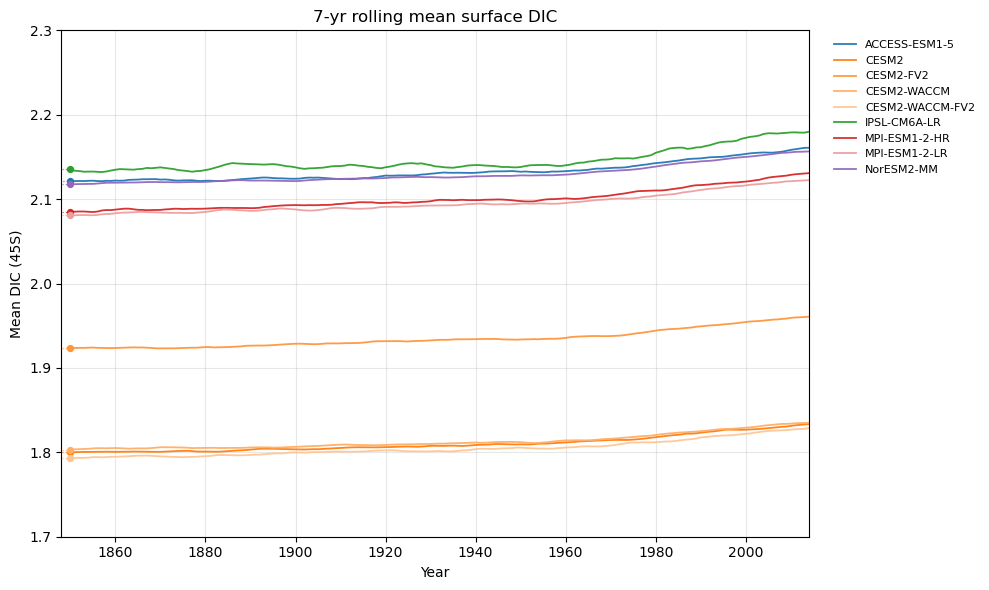

In [36]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

indir = "/g/data/jk72/zc0441/Subject_3/data"
win = 7

def get_flip_year_from_smoothed(sm):
    y = sm.values
    yrs = sm["year"].values
    valid = np.isfinite(y)
    y_v = y[valid]
    yrs_v = yrs[valid]
    if len(y_v) < 2:
        return None
    sc = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]
    if len(sc) == 0:
        return None
    k = sc[0]
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    return x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

def blend_with_white(rgb, t):
    """t=0 -> original color, t=1 -> white"""
    r, g, b = rgb
    return (r + (1 - r) * t, g + (1 - g) * t, b + (1 - b) * t)

# --- group models by series ---
model_series = {}
for model in model_list_1:
    series = model.split("-")[0]
    model_series.setdefault(series, []).append(model)

# --- base color per series (tab10 cycles automatically) ---
series_names = sorted(model_series.keys())
base_colors = plt.cm.tab10.colors
series_color = {s: base_colors[i % len(base_colors)] for i, s in enumerate(series_names)}

# --- assign a distinct shade to each model within its series ---
model_color = {}
for s in series_names:
    ms = sorted(model_series[s])
    if len(ms) == 1:
        model_color[ms[0]] = series_color[s]
    else:
        # lightness ramp within series: small spread so they look "similar"
        ts = np.linspace(0.0, 0.55, len(ms))  # 0=base, 0.55=lighter
        for m, t in zip(ms, ts):
            model_color[m] = blend_with_white(series_color[s], t)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 6))

for model in model_list_1:
    fn = f"{indir}/{model}/dissic_south45_annual_1850_2014_hist.nc"
    ds = xr.open_dataset(fn)

    if "IPSL" in model:
        lev_coord = 'olevel'
        ts = ds["dissic_aw_mean_by_year"].isel(olevel= 0)
        
    else:
        lev_coord = 'lev'
        ts = ds["dissic_aw_mean_by_year"].isel(lev= 0)
        
    
    sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

    c = model_color[model]

    # line
    ax.plot(sm["year"], sm.values, lw=1.3, alpha=0.95, color=c, label=model)

    # start point + horizontal guide
    y = sm.values
    yrs = sm["year"].values
    valid = np.isfinite(y)
    if valid.any():
        i0 = np.where(valid)[0][0]
        x_start = yrs[i0]
        y_start = y[i0]

        ax.scatter([x_start], [y_start], s=18, marker="o", color=c, zorder=5)

        ax.hlines(
            y_start,
            xmin=ax.get_xlim()[0],
            xmax=x_start,
            colors=c,
            linestyles=":",
            linewidth=0.9,
            alpha=0.8,
        )

    # flip year + vertical guide
    flip_year = get_flip_year_from_smoothed(sm)
    if flip_year is not None:
        ax.scatter([flip_year], [0], s=22, marker="x", color=c, zorder=6)

        # ax.vlines(
        #     flip_year,
        #     ymin=ax.get_ylim()[0],
        #     ymax=0,
        #     colors=c,
        #     linestyles="--",
        #     linewidth=0.9,
        #     alpha=0.8,
        # )

ax.axhline(0, color="0.5", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Mean DIC (45S)")
ax.set_title(f"{win}-yr rolling mean surface DIC")
ax.grid(True, alpha=0.3)
ax.set_xlim(1848, 2014)
ax.set_ylim(1.7, 2.3)


# legend: all models, but grouped by color family visually
ax.legend(frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()


## 6. Model-specific analysis (ACCESS-ESM1-5)


# Process (ACCESS only)

## Pre

In [33]:
model = 'ACCESS-ESM1-5'

In [150]:
fgco2 = zt_fgco2_hist_fs38.open_model(model)['fgco2']
tos = zt_tos_hist_fs38.open_model(model)['tos']
sos = zt_sos_hist_fs38.open_model(model)['sos']
dissic = zt_dissic_hist_fs38.open_model(model)['dissic']
wfo = zt_wfo_hist_fs38.open_model(model)['wfo']
hfds = zt_hfds_hist_fs38.open_model(model)['hfds']
density = gsw.rho(sos, tos, 0).compute()

# fn = f"/g/data/jk72/zc0441/Subject_2/data/{model}/areacello_historical_gn.nc"
# areacello = xr.open_dataset(fn)['areacello']

path ='/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r1i1p1f1/Ofx/areacello/gn/latest/areacello_Ofx_ACCESS-ESM1-5_historical_r1i1p1f1_gn.nc'
areacello = xr.open_dataset(path)['areacello']

### 6.1 Analysis


## fgco2 timeseries

In [161]:
# areacello
fgco2_area =  fgco2 * areacello
fgco2_area = fgco2_area.assign_coords(
    latitude=fgco2.latitude,
    longitude=fgco2.longitude
)

In [163]:
# fgco2_area.isel(time =0).plot()
# areacello.plot()

In [154]:
# fgco2_area 

In [41]:
# do not weight area direct use the variale multied, fgco2_area, and sum it in each 

In [42]:
# fgco2_area

In [43]:
# fgco2_area.groupby('time.year')

In [164]:
fgco2_area_mean_by_year = (
    fgco2_area
    .where(fgco2_area.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .mean(dim=["i", "j"])        # 空间平均
    .compute()
)

fgco2_area_sum_by_year = (
    fgco2_area
    .where(fgco2_area.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .sum(dim=["i", "j"])        
    .compute()
)

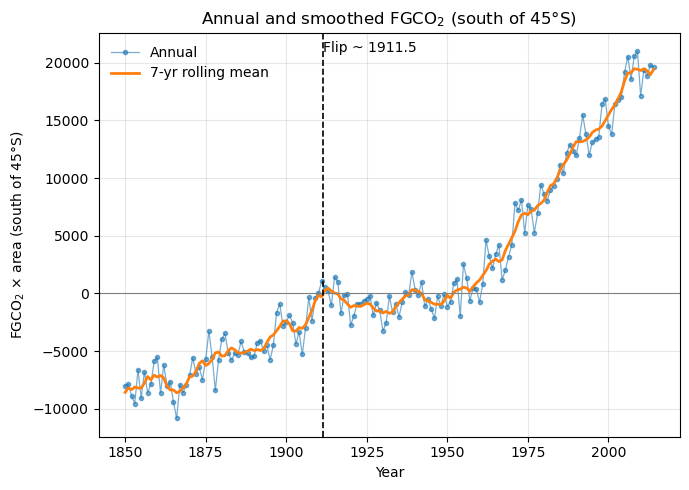

Flip year (zero crossing of smoothed series): 1911.510972836085


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# --- ensure 1D series on 'year' ---
ts = fgco2_area_sum_by_year

# --- smoothing window (years). Choose 5, 7, 9, 11 depending on how smooth you want it ---
win = 7

# centered rolling mean; min_periods avoids dropping the ends too aggressively
sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

# --- find flip point: first year where smoothed series crosses 0 ---
y = sm.values
yrs = sm["year"].values

valid = np.isfinite(y)
yrs_v = yrs[valid]
y_v = y[valid]

# sign-change indices between consecutive points
sign_change = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]

flip_year = None
if len(sign_change) > 0:
    k = sign_change[0]
    # linear interpolation for a more precise crossing year
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    flip_year = x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ts["year"], ts.values, marker="o", ms=3, lw=0.9, alpha=0.6, label="Annual")
ax.plot(sm["year"], sm.values, lw=2.0, label=f"{win}-yr rolling mean")
ax.axhline(0, color="0.5", lw=0.8)

if flip_year is not None:
    ax.axvline(flip_year, color="k", lw=1.2, ls="--")
    ax.text(
        flip_year, 0.98, f"Flip ~ {flip_year:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top"
    )

ax.set_xlabel("Year")
ax.set_ylabel("FGCO$_2$ × area (south of 45°S)")
ax.set_title("Annual and smoothed FGCO$_2$ (south of 45°S)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Flip year (zero crossing of smoothed series):", flip_year)


### 6.2 Visualization


In [46]:
# 1) 只取 45°S 以南
fgco2_south45 = fgco2.where(fgco2.latitude < -45)

# 2) 先做 zonal mean（沿经度平均）
# 如果你的经度维度是 i（常见于 curvilinear grid）
fgco2_zonal = fgco2_south45.mean(dim="i")

# 原始二维纬度
lat2d = fgco2_south45.latitude

# 沿经度方向（i）取平均，得到 1D 纬度 (j)
lat1d = lat2d.mean(dim="i")

# 重新赋回给 zonal-mean 结果
fgco2_zonal = fgco2_zonal.assign_coords(latitude=lat1d)

# 3) 按年平均
fgco2_zonal_mean_by_year = (
    fgco2_zonal
    .groupby("time.year")
    .mean("time")
)

fgco2_zonal_mean_by_year


<xarray.DataArray 'fgco2' (year: 165, j: 300)> Size: 198kB
dask.array<transpose, shape=(165, 300), dtype=float32, chunksize=(1, 300), chunktype=numpy.ndarray>
Coordinates:
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * j         (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
    depth     float64 8B 0.0
    latitude  (j) float64 2kB dask.array<chunksize=(300,), meta=np.ndarray>

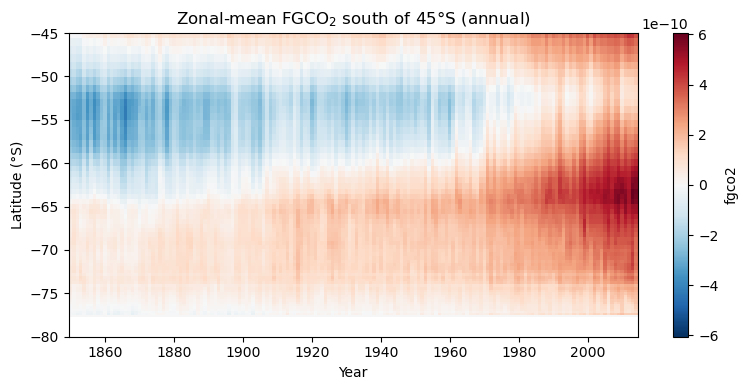

In [47]:
plt.figure(figsize=(8, 4))
fgco2_zonal_mean_by_year.plot(
    x="year",
    y="latitude",
    # cmap="cmocean.balance",
    add_colorbar=True
)

plt.title("Zonal-mean FGCO$_2$ south of 45°S (annual)")
plt.xlabel("Year")
plt.ylabel("Latitude (°S)")

# 只显示 45°S 到南极
plt.ylim(-80, -45)

# 如果纬度是从北到南递增，可强制翻转
# plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


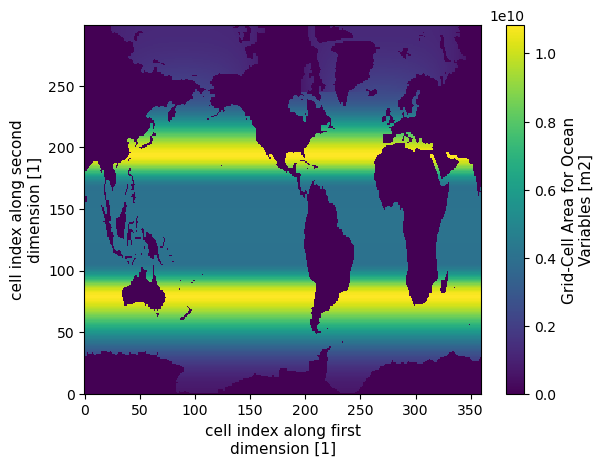

In [175]:
areacello.fillna(0.0).plot()

In [48]:
# fgco2.where(mask)

In [192]:
import numpy as np
import xarray as xr

def project_fgco2_to_density_year(
    fgco2_m, sigma_m, areacello,
    lat,
    south_of=-45,
    rho_min=1026, rho_max=1031, drho=0.1,
    time_name="time",
):
    so_mask = lat <= south_of

    fg = fgco2_m.where(so_mask)
    sg = sigma_m.where(so_mask)

    # IMPORTANT: weights must not contain NaNs
    w  = areacello.where(so_mask).fillna(0.0)

    rho_edges = np.arange(rho_min, rho_max + drho, drho)
    rho_mid   = 0.5 * (rho_edges[:-1] + rho_edges[1:])

    space_dims = tuple(d for d in fg.dims if d != time_name)  # e.g. ('j','i')

    out = []
    for r0, r1 in zip(rho_edges[:-1], rho_edges[1:]):
        m = (sg >= r0) & (sg < r1)

        # fg_bin_t = fg.where(m).weighted(w).mean(space_dims)
        fg_bin_t = fg.where(m).mean(space_dims)
        fg_bin_y = fg_bin_t.groupby(f"{time_name}.year").mean(time_name)

        out.append(fg_bin_y)

    da = xr.concat(out, dim="density").assign_coords(density=("density", rho_mid))
    return da  # (year, density)


# ---- usage ----
# fgco2_monthly: (time, j, i)
# sigma_monthly: (time, j, i)  e.g., surface density sigma0
# areacello: (j, i)
# latitude: either fgco2_monthly['latitude'] or a separate lat array (j or j,i)

fgco2_rho_year = project_fgco2_to_density_year(
    fgco2_m=fgco2,
    sigma_m=density,
    areacello=areacello,
    lat=fgco2["latitude"],   # or sigma_monthly["latitude"]
    south_of=-45,
    rho_min=1025, rho_max=1029, drho=0.1,
    time_name="time",
).compute()


In [193]:
# wmf_total_block_s  = smooth_along_density(wmf_total_block, win=5)
fgco2_rho_year_s= smooth_along_density(fgco2_rho_year, win=5)

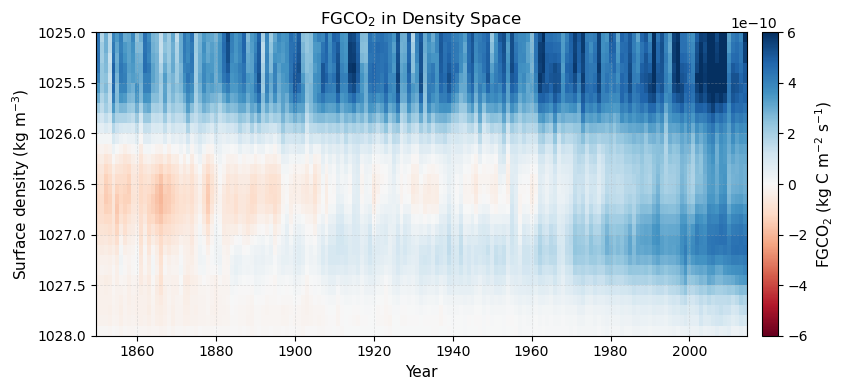

In [194]:
da_for_plot = fgco2_rho_year_s
da_for_plot = da_for_plot.where(np.isfinite(da_for_plot))
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 4))

im = da_for_plot.plot(
    ax=ax,
    x="year",
    y="density",
    vmax = 6e-10,
    vmin = -6e-10,
    
    cmap="RdBu",   # or any diverging map you prefer
    shading="auto",
    add_colorbar=False,
)

# Colorbar with label
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"FGCO$_2$ (kg C m$^{-2}$ s$^{-1}$)")

# Axis formatting
ax.set_ylim(1025, 1028)
ax.set_title(r"FGCO$_2$ in Density Space")
ax.set_xlabel("Year")
ax.set_ylabel(r"Surface density (kg m$^{-3}$)")
ax.invert_yaxis()  # denser classes lower, like a water-mass view

# Light grid for readability
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

fig.tight_layout()
plt.show()


In [179]:
# density.isel(time = 0).plot()


In [168]:
# zt_areacello_hist_fs38


In [136]:
# dissic.isel(time = 0).isel(lev = 0).plot()

In [188]:
# plot_south_polar_auto(fgco2.isel(time = 0), cmap = "RdBu")

In [187]:
# plot_south_polar_auto(fgco2_area.isel(time = 0), cmap = "RdBu")

In [165]:
import numpy as np
import xarray as xr

def sum_fgco2_area_in_density_bins_by_year(
    fgco2_area_m, sigma_m,
    lat,
    south_of=-45,
    rho_min=1025, rho_max=1029, drho=0.1,
    time_name="time",
):
    """
    Sum fgco2_area within density bins south of 45S, then annual-mean by year.

    Inputs:
      fgco2_area_m: (time, j, i) = fgco2 * area (already multiplied)
      sigma_m:      (time, j, i) surface density (monthly)
      lat:          (j) or (j,i) latitude field compatible with fgco2_area_m
    Returns:
      DataArray dims (year, density)
    """
    so_mask = lat <= south_of

    fg = fgco2_area_m.where(so_mask)
    sg = sigma_m.where(so_mask)

    rho_edges = np.arange(rho_min, rho_max + drho, drho)
    rho_mid   = rho_edges[:-1]

    space_dims = tuple(d for d in fg.dims if d != time_name)  # e.g. ('j','i')

    out = []
    for r0, r1 in zip(rho_edges[:-1], rho_edges[1:]):
        m = (sg >= r0) & (sg < r1)

        # monthly summed flux in this density bin
        # fg_bin_t = fg.where(m).weighted(w).mean(space_dims)
        
        fg_bin_t = fg.where(m).sum(space_dims) #, skipna=True, min_count=1)

        # convert monthly -> annual mean (if you want annual SUM instead, see note below)
        fg_bin_y = fg_bin_t.groupby(f"{time_name}.year").sum(time_name)/12

        out.append(fg_bin_y)

    da = xr.concat(out, dim="density").assign_coords(density=("density", rho_mid))
    return da

# ---- usage ----
fgco2_rho_year = sum_fgco2_area_in_density_bins_by_year(
    fgco2_area_m=fgco2_area,          # monthly (time,j,i)
    sigma_m=density,            # monthly (time,j,i)
    lat=fgco2_area["latitude"],       # (j) or (j,i)
    south_of=-45,
    rho_min=1025, rho_max=1029, drho=0.1,
    time_name="time",
).compute()


In [111]:
# fgco2_area["latitude"]
# density

In [106]:
# fgco2_rho_year

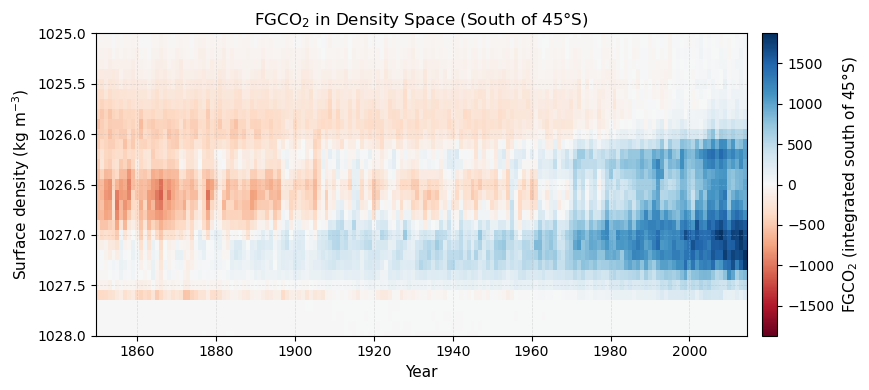

In [166]:
da_for_plot = fgco2_rho_year
da_for_plot = da_for_plot.where(np.isfinite(da_for_plot))
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 4))

im = da_for_plot.plot(
    ax=ax,
    x="year",
    y="density",
    cmap="RdBu",   # or any diverging map you prefer
    shading="auto",
    add_colorbar=False,
    # vmax = 1000,
    # vmin = -1000
)

# Colorbar with label
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"FGCO$_2$ (integrated south of 45°S)")

# Axis formatting
ax.set_ylim(1025, 1028)
# ax.set_xlim(-1025, 1028)
ax.set_title(r"FGCO$_2$ in Density Space (South of 45°S)")
ax.set_xlabel("Year")
ax.set_ylabel(r"Surface density (kg m$^{-3}$)")
ax.invert_yaxis()  # denser classes lower, like a water-mass view

# Light grid for readability
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

fig.tight_layout()
plt.show()


### 6.3 DIC diagnostics


## dissic timeseries

In [75]:
dissic.lev

<xarray.DataArray 'lev' (lev: 50)> Size: 400B
array([5.000000e+00, 1.500000e+01, 2.500000e+01, 3.500000e+01, 4.500000e+01,
       5.500000e+01, 6.500000e+01, 7.500000e+01, 8.500000e+01, 9.500000e+01,
       1.050000e+02, 1.150000e+02, 1.250000e+02, 1.350000e+02, 1.450000e+02,
       1.550000e+02, 1.650000e+02, 1.750000e+02, 1.850000e+02, 1.950000e+02,
       2.050000e+02, 2.168468e+02, 2.413490e+02, 2.807807e+02, 3.432505e+02,
       4.273156e+02, 5.367156e+02, 6.654141e+02, 8.127816e+02, 9.690651e+02,
       1.130935e+03, 1.289605e+03, 1.455770e+03, 1.622926e+03, 1.801558e+03,
       1.984855e+03, 2.182905e+03, 2.388417e+03, 2.610935e+03, 2.842564e+03,
       3.092205e+03, 3.351295e+03, 3.628058e+03, 3.913264e+03, 4.214495e+03,
       4.521918e+03, 4.842566e+03, 5.166130e+03, 5.499245e+03, 5.831294e+03])
Coordinates:
  * lev      (lev) float64 400B 5.0 15.0 25.0 ... 5.166e+03 5.499e+03 5.831e+03
Attributes:
    bounds:         lev_bnds
    units:          m
    axis:           Z
    positive:       down
    long_name:      ocean depth coordinate
    standard_name:  depth

In [76]:
dissic_suf = dissic.sel(lev =5)

dissic_mean_by_year = (
    dissic_suf
    .where(dissic_suf.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .mean(dim=["i", "j"])        # 空间平均
    .compute()
)

In [77]:
dissic_100m = dissic.sel(lev =95)

dissic_100m_mean_by_year = (
    dissic_100m
    .where(dissic_100m.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .mean(dim=["i", "j"])        # 空间平均
    .compute()
)

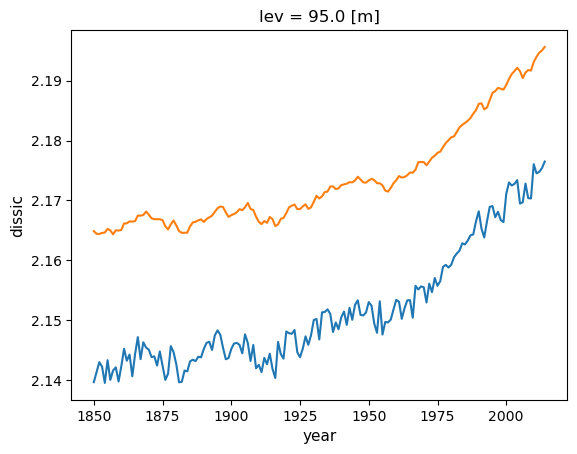

In [78]:
dissic_mean_by_year.plot()
dissic_100m_mean_by_year.plot()

# fgco2_area_mean_by_year.plot()


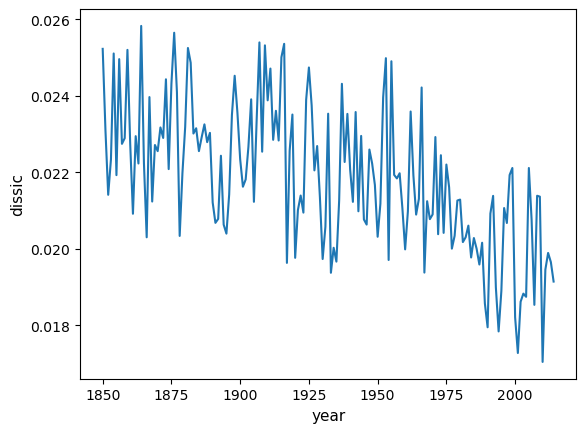

In [79]:
(dissic_100m_mean_by_year - dissic_mean_by_year).plot()

In [80]:
# 0) 只保留 600 m 以内的层
dissic_600 = dissic.where(dissic.lev <= 5000, drop=True)

# 1) 只取 45°S 以南
dissic_south45 = dissic_600.where(dissic_600.latitude < -45)

# 2) 做 zonal mean（沿经度平均）
# 若经度维度是 i（curvilinear grid 常见）
dissic_zonal = dissic_south45.mean(dim="i")

# 原始二维纬度
lat2d = dissic_south45.latitude

# 沿经度方向（i）取平均，得到 1D 纬度 (j)
lat1d = lat2d.mean(dim="i")

# 重新赋回给 zonal-mean 结果
dissic_zonal = dissic_zonal.assign_coords(latitude=lat1d)

# 3) 按年平均
dissic_zonal_mean_by_year = (
    dissic_zonal
    .groupby("time.year")
    .mean("time")
    .compute()
)

dissic_zonal_mean_by_year


<xarray.DataArray 'dissic' (year: 165, lev: 47, j: 300)> Size: 9MB
array([[[      nan, 2.2005126, 2.2050068, ...,       nan,       nan,
               nan],
        [      nan, 2.2013748, 2.2057867, ...,       nan,       nan,
               nan],
        [      nan, 2.2021153, 2.2067559, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 2.195988 , 2.2020922, ...,       nan,       nan,
               nan],
        [      nan, 2.197825 , 2.203702 , ...,       nan,       nan,
               nan],
        [      nan, 2.1997626, 2.2054574, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan, 2.202543 , 2.2093763, ...,       nan,       nan,
               nan],
        [      nan, 2.2047355, 2.2112343, ...,       nan,       nan,
               nan],
        [      nan, 2.206792 , 2.2131858, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * lev       (lev) float64 376B 5.0 15.0 25.0 ... 4.214e+03 4.522e+03 4.843e+03
  * j         (j) int32 1kB 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
    latitude  (j) float64 2kB -77.88 -77.63 -77.38 -77.13 ... 78.75 78.82 78.86

In [81]:
# Align on (year, j)
dissic_z, fgco2_z = xr.align(
    dissic_zonal_mean_by_year,
    fgco2_zonal_mean_by_year,
    join="inner"
)


In [82]:
dissic_z_detrended, dissic_z_trend = detrend_along_dim(
    dissic_z, dim="year"
)

fgco2_tot_detrended, fgco2_tot_trend = detrend_along_dim(
    fgco2_tot, dim="year"
)

NameError: name 'fgco2_tot' is not defined

In [ ]:
r_lev_lat = xr.corr(dissic_z, fgco2_z, dim="year").compute()


In [ ]:
plt.figure(figsize=(8, 6))
r_lev_lat.plot(
    x="latitude",
    y="lev",
    # cmap="cmocean.balance",
    vmin=0.7, vmax=1
)

plt.title("Correlation between DIC and FGCO$_2$\n(annual, south of 45°S)")
plt.xlabel("Latitude (°S)")
plt.ylabel("Depth (m)")

plt.xlim(-80, -45)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
# 1) 只取 45°S 以南
fgco2_area_south45 = fgco2_area.where(fgco2_area.latitude < -45)

# 2) 先做 zonal mean（沿经度平均）
# 如果你的经度维度是 i（常见于 curvilinear grid）
fgco2_area_zonal = fgco2_area_south45.sum(dim="i")

# 原始二维纬度
lat2d = fgco2_area_south45.latitude

# 沿经度方向（i）取平均，得到 1D 纬度 (j)
lat1d = lat2d.mean(dim="i")

# 重新赋回给 zonal-mean 结果
fgco2_area_zonal = fgco2_area_zonal.assign_coords(latitude=lat1d)

# 3) 按年平均
fgco2_area_zonal_mean_by_year = (
    fgco2_zonal
    .groupby("time.year")
    .mean("time")
)

fgco2_area_zonal_mean_by_year


In [ ]:
# If fgco2_zonal_mean_by_year is already area-weighted (fgco2 * area),
# then summing over latitude gives total Southern Ocean flux.
fgco2_total_by_year = fgco2_area_zonal_mean_by_year.sum(dim="j").compute()

dissic_z, fgco2_tot = xr.align(
    dissic_zonal_mean_by_year,
    fgco2_total_by_year,
    join="inner"
)


In [ ]:
dissic_z_detrended, dissic_z_trend = detrend_along_dim(
    dissic_z, dim="year"
)

fgco2_tot_detrended, fgco2_tot_trend = detrend_along_dim(
    fgco2_tot, dim="year"
)

In [ ]:
r_lev_lat_total = xr.corr(dissic_z_detrended, fgco2_tot_detrended, dim="year").compute()
# r_lev_lat_total = xr.corr(dissic_z, fgco2_tot, dim="year").compute()



In [ ]:
plt.figure(figsize=(8, 6))
r_lev_lat_total.plot(
    x="latitude",
    y="lev",
    # cmap="cmocean.balance",
    vmin=0, vmax=1
)

plt.title("Correlation between total Southern Ocean FGCO$_2$\n"
          "and DIC at each latitude and depth (annual)")
plt.xlabel("Latitude (°S)")
plt.ylabel("Depth (m)")

plt.xlim(-80, -45)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
# dissic.groupby("time.year").mean("time").mean(dim=["i"]) 
d_dissic=dissic_zonal_mean_by_year.sel(year = 2014) - dissic_zonal_mean_by_year.sel(year = 1850)
plt.figure(figsize=(8, 6))
d_dissic.plot(
    x="latitude",
    y="lev",
    # cmap="cmocean.balance",
    vmin=0, vmax=0.04
)

plt.title("$\Delta$ DIC between 2014-1850")
plt.xlabel("Latitude (°S)")
plt.ylabel("Depth (m)")

plt.xlim(-80, -45)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



In [ ]:
da_plot = dissic_zonal_mean_by_year.sel(year = 2014)
plt.figure(figsize=(8, 6))
da_plot.plot(
    x="latitude",
    y="lev",
    # cmap="cmocean.balance",
    vmin=2.0, vmax=2.3
)

plt.title("Correlation between total Southern Ocean FGCO$_2$\n"
          "and DIC at each latitude and depth (annual)")
plt.xlabel("Latitude (°S)")
plt.ylabel("Depth (m)")

plt.xlim(-80, -45)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


### 6.4 Cross-variable analysis


## fgco2 vs dissic

In [42]:
# 对齐年份，只保留两者共有的 year
dissic_y, fgco2_y = xr.align(
    dissic_mean_by_year,
    fgco2_area_mean_by_year,
    join="inner"
)

# 计算皮尔逊相关系数
r = xr.corr(dissic_y, fgco2_y, dim="year")

r

from scipy.stats import pearsonr

# 转为 numpy（此时是一维时间序列）
x = dissic_y.values
y = fgco2_y.values

mask = np.isfinite(x) & np.isfinite(y)
r_val, p_val = pearsonr(x[mask], y[mask])

r_val, p_val


(0.930255, 7.080835388556657e-73)

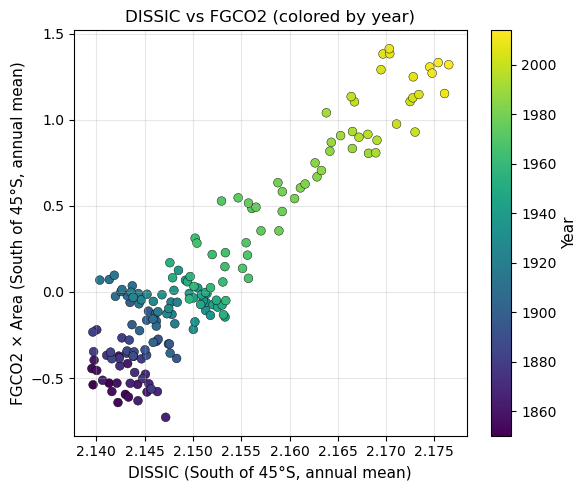

In [43]:
# 对齐年份
dissic_y, fgco2_y = xr.align(
    dissic_mean_by_year,
    fgco2_area_mean_by_year,
    join="inner"
)

years = dissic_y["year"].values

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    dissic_y.values,
    fgco2_y.values,
    c=years,
    cmap="viridis",
    s=40,
    edgecolor="k",
    linewidth=0.3
)

plt.xlabel("DISSIC (South of 45°S, annual mean)")
plt.ylabel("FGCO2 × Area (South of 45°S, annual mean)")
plt.title("DISSIC vs FGCO2 (colored by year)")

cbar = plt.colorbar(sc)
cbar.set_label("Year")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.5 Water-mass transformation (WMT)


## WMT

In [84]:
tos_dec = decadal_block_monthly_mean(tos).compute()
sos_dec = decadal_block_monthly_mean(sos).compute()
hfds_dec = decadal_block_monthly_mean(hfds).compute()
wfo_dec = decadal_block_monthly_mean(wfo).compute()



In [85]:
density_dec = gsw.rho(sos_dec, tos_dec, 0)


In [86]:
data_dict={}
data_dict[model]={}
data_dict[model]['density_monthly'] = density_dec
data_dict[model]['tos_monthly'] = tos_dec
data_dict[model]['sos_monthly'] = sos_dec
data_dict[model]['hfds_area_monthly'] = hfds_dec * areacello
data_dict[model]['wfo_area_monthly'] = wfo_dec * areacello






In [87]:
# data_dict[model]['hfds_area_monthly']

In [88]:
wmt_hfds_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="hfds_area_monthly", v_type="heat") #, block_years=10)
wmt_wfo_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="wfo_area_monthly", v_type="water") #, block_years=10)

# wmt_block: dims ('block','density')

In [89]:


wmt_wfo_block_s   = smooth_along_density(wmt_wfo_block,  win=5)
wmt_hfds_block_s  = smooth_along_density(wmt_hfds_block, win=5)


In [90]:
wmt_total_block =  wmt_wfo_block + wmt_hfds_block
wmf_total_block =  tr_to_fr(wmt_total_block)
# wmf_total_block_s  = smooth_along_density(wmf_total_block_s, win=5)

wmt_total_block_s =  wmt_wfo_block_s + wmt_hfds_block_s
wmf_total_block_s =  tr_to_fr(wmt_total_block_s)
wmf_total_block_s  = smooth_along_density(wmf_total_block_s, win=5)


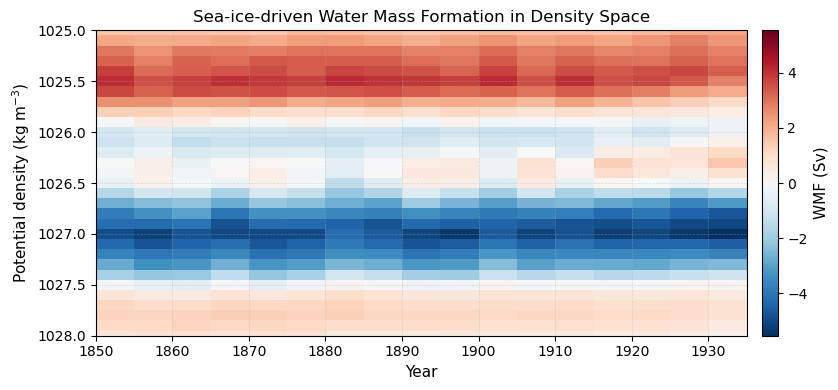

In [91]:
import matplotlib.pyplot as plt

block_years = 5
start_year = 1850

years = start_year + (wmt_wfo_block["block"] + 0.5) * block_years

# assign "year" as a coordinate along "block"
da = wmf_total_block_s.assign_coords(year=("block", years.data))

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 4))

im = da.plot(
    ax=ax,
    x="year",
    y="density",
    shading="auto",
    add_colorbar=False,
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"WMF (Sv)")

ax.set_title("Sea-ice-driven Water Mass Formation in Density Space")
ax.set_xlabel("Year")  # <-- since x="year"
ax.set_ylabel(r"Potential density (kg m$^{-3}$)")

ax.set_ylim(1028, 1025)  # cleaner than set_ylim + invert_yaxis
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

fig.tight_layout()
plt.show()


In [92]:
# tr_to_fr(wmt_total_block )

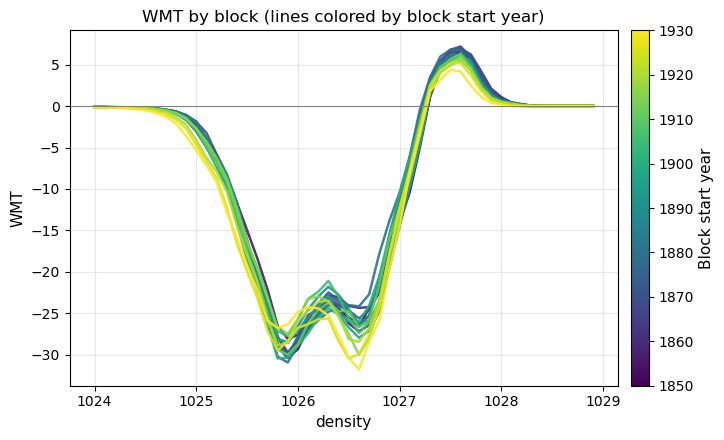

In [93]:
ax = plot_wmt_blocks_colored_by_year(wmt_total_block_s, start_year=1850, block_years=5)




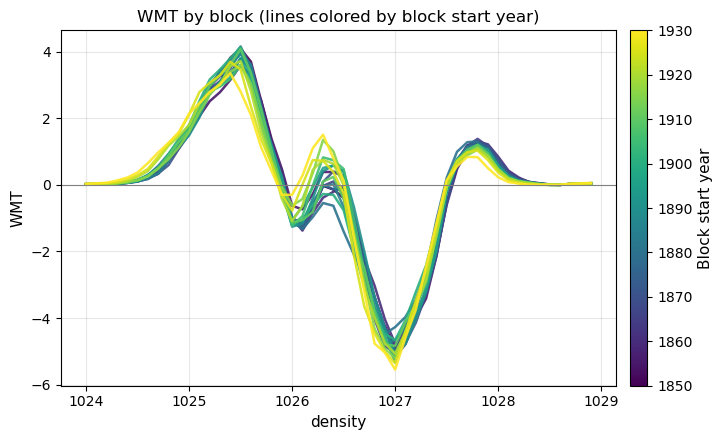

In [94]:

ax = plot_wmt_blocks_colored_by_year(wmf_total_block_s, start_year=1850, block_years=5)


In [95]:
# wmf_total_block_sift < 0

In [96]:
wmf_total_block_sift = wmf_total_block.where(wmf_total_block.density > 1026.2)
wmf_total_block_sift_s = wmf_total_block_s.where(wmf_total_block.density > 1026.2)

destruction_by_block = -wmf_total_block_sift.where(wmf_total_block_sift < 0).sum(dim = 'density')
destruction_by_block_s = -wmf_total_block_sift_s.where(wmf_total_block_sift_s < 0).sum(dim = 'density')



In [97]:
# wmt_total_block 

In [98]:
wmt_total_block_sift = wmt_total_block #.where(wmt_total_block.density > 1026.2)
destruction_by_block_2= wmt_total_block_sift.max(dim = "density") - wmt_total_block_sift.min(dim = "density")

In [99]:
destruction_by_block_3 = wmf_total_block_s.where(wmf_total_block.density > 1026.4).where(wmf_total_block.density < 1027.5).sum(dim = 'density')
destruction_by_block_4 = -wmf_total_block_s.where(wmf_total_block_s < 0).where(wmf_total_block.density < 1027.5).sum(dim = 'density') #.where(wmf_total_block.density > 1026.4).sum(dim = 'density')

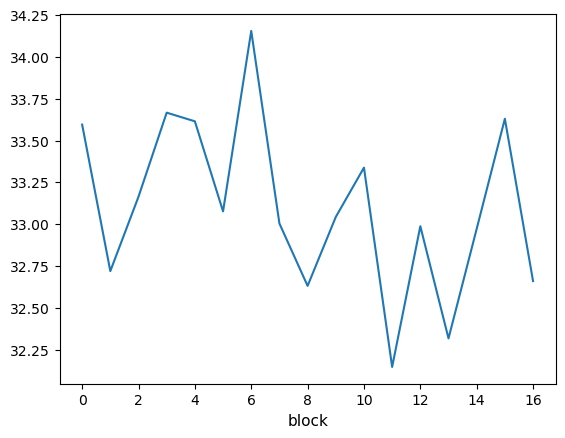

In [100]:
destruction_by_block_4.plot()

In [101]:
da = dissic_mean_by_year

block = ((da["year"] - da["year"].min()) // 5).astype("int32")
dissic_mean_by_block = (
    da.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

fgco2_mean_by_block = (
    fgco2_area_mean_by_year.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

fgco2_area_sum_by_block = (
    fgco2_area_sum_by_year.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

fgco2_rho_by_block = (
    fgco2_rho_year.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)


In [102]:
p1 = fgco2_rho_by_block.where(fgco2_rho_by_block.density > 1026.2)
p2 = p1.where(wmf_total_block.density > 1026.2)
fgco2_rho_sum_in_destruction = p2.where(wmf_total_block_sift < 0)


In [103]:
import numpy as np
import xarray as xr

def _standardize_density_coord(da, density_dim="density", step=0.1, decimals=1):
    """
    标准化 density bin centre 标签到规则 step 网格（默认 0.1），不插值、不改数据，只改坐标。
    自动识别并修正“半格偏移”（例如 1025.05 -> 1025.0, 1025.15 -> 1025.1）。
    若标准化后出现重复 density（例如四舍五入导致），用 groupby(density).mean 合并（仍不插值）。
    """
    d = da[density_dim].values.astype(float)

    # 判断是否是“半格偏移”：density/step 的小数部分接近 0.5
    frac = (d / step) - np.floor(d / step)
    is_half_shift = np.nanmedian(np.isclose(frac, 0.5, atol=1e-6))

    # 若是半格偏移，则整体平移 -0.5*step，再 round 到 step 网格
    if is_half_shift:
        d_std = np.round((d - 0.5 * step) / step) * step
    else:
        d_std = np.round(d / step) * step

    d_std = np.round(d_std, decimals)

    da2 = da.assign_coords({density_dim: (density_dim, d_std)})

    # 如果 round 之后有重复 density，合并（不插值，只是把同一 bin 的值做平均）
    if len(np.unique(d_std)) < len(d_std):
        da2 = da2.groupby(density_dim).mean()

    return da2


def align_fg_wmf_no_interp(fg, wmf_total_block, step=0.1, decimals=1):
    """
    1) 标准化两者 density 坐标（不插值）
    2) 统一维度顺序为 (density, block)
    3) 按共同 density & block 做 inner align
    """
    fg2  = _standardize_density_coord(fg, step=step, decimals=decimals)
    wmf2 = _standardize_density_coord(wmf_total_block, step=step, decimals=decimals)

    # 统一维度顺序（如果有 block）
    if "block" in fg2.dims:
        fg2 = fg2.transpose("density", "block", ...)
    if "block" in wmf2.dims:
        wmf2 = wmf2.transpose("density", "block", ...)

    fg_aligned, wmf_aligned = xr.align(fg2, wmf2, join="inner")

    return fg_aligned, wmf_aligned


# ====== 直接用 ======
fg_aligned, wmf_aligned = align_fg_wmf_no_interp(fg, wmf_total_block)

print("fg_aligned:", fg_aligned.dims, fg_aligned.sizes)
print("wmf_aligned:", wmf_aligned.dims, wmf_aligned.sizes)
print("density identical:", fg_aligned.density.equals(wmf_aligned.density))
print("block identical:", fg_aligned.block.equals(wmf_aligned.block))


NameError: name 'fg' is not defined

In [ ]:
fg_by_block = fg_aligned.where(fg_aligned.density > 1026.5).where(fg_aligned.density < 1027.6).sum(dim = 'density')
wmf_by_block_1 = -wmf_aligned.where(fg_aligned.density > 1026.5).where(fg_aligned.density < 1027.6).sum(dim = 'density')
#     wmf.where(wmf_total_block.density > 1026.2)
# .where(wmf_total_block_sift < 0).sum(dim = 'density')

In [ ]:
dissic_mean_by_block_detrended, dissic_trend = detrend_along_dim(
    dissic_mean_by_block, dim="block"
)

fgco2_mean_by_block_detrended, fgco2_trend = detrend_along_dim(
    fgco2_mean_by_block, dim="block"
)

destruction_by_block_2_detrended, fgco2_trend = detrend_along_dim(
    destruction_by_block_2, dim="block"
)

In [ ]:
fg_by_block
# destruction_by_block_s

In [ ]:
# plt.figure()
# plt.plot(fg_by_block.where(dissic_mean_by_block.block<10), destruction_by_block_s.where(dissic_mean_by_block.block<10), marker="o")
# plt.xlabel("FGCO2")
# plt.ylabel("Destruction")
# plt.tight_layout()
# plt.show()


In [ ]:
from scipy.stats import pearsonr, linregress
import numpy as np

# 对齐
dissic_y, ventilation_y = xr.align(
    # dissic_mean_by_block,
    # fgco2_area_sum_by_block,
    # destruction_by_block_2,
    # dissic_mean_by_block.where(dissic_mean_by_block.block>23),
    # fgco2_mean_by_block.where(dissic_mean_by_block.block>23),
    # destruction_by_block_s.where(dissic_mean_by_block.block>23),
    # fgco2_area_sum_by_block.where(dissic_mean_by_block.block<12),
    # destruction_by_block.where(dissic_mean_by_block.block<12),
    # dissic_mean_by_block_detrended,
    # destruction_by_block_2_detrended 
    # destruction_by_block_2,
    fg_by_block, #.where(dissic_mean_by_block.block>23),
    -destruction_by_block_3, #.where(dissic_mean_by_block.block>23),
    join="inner"
)

years = dissic_y["block"].values * 5 + 1850

# 计算相关（去掉 NaN）
x = ventilation_y.values
y = dissic_y.values
mask = np.isfinite(x) & np.isfinite(y)

r, p = pearsonr(x[mask], y[mask])

# 线性回归
slope, intercept, _, _, _ = linregress(x[mask], y[mask])
xx = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 100)
yy = slope * xx + intercept

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    x, y,
    c=years,
    cmap="viridis",
    s=40,
    edgecolor="k",
    linewidth=0.3
)

# 回归线
plt.plot(xx, yy, color="k", lw=1.5, zorder=3)

plt.xlabel("Ventilation by WMT (South of 45°S)")
# plt.ylabel("Surface DIC (South of 45°S, decadal mean)")
plt.ylabel("Surface carbon flux(South of 45°S)")
plt.title("DIC vs Ventilation (colored by decade)")

# 在图中标注相关系数
plt.text(
    0.65, 0.95,
    f"r = {r:.2f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

cbar = plt.colorbar(sc)
cbar.set_label("Decade start year")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import pearsonr
import numpy as np

# 对齐
dissic_y, ventilation_y = xr.align(
    fgco2_mean_by_block,
    # fgco2_mean_by_block_detrended,
    destruction_by_block_2,
    join="inner"
)

years = dissic_y["block"].values * 10 + 1850

# 计算相关（去掉 NaN）
x = ventilation_y.values
y = dissic_y.values
mask = np.isfinite(x) & np.isfinite(y)

r, p = pearsonr(x[mask], y[mask])

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    x, y,
    c=years,
    cmap="viridis",
    s=40,
    edgecolor="k",
    linewidth=0.3
)

plt.xlabel("Ventilation by WMT (South of 45°S, decadal mean)")
plt.ylabel("Surface DIC (South of 45°S, decadal mean)")
plt.title("fgco2 vs Ventilation (colored by decade)")

# 在图中标注相关系数
plt.text(
    0.65, 0.95,
    f"r = {r:.2f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

cbar = plt.colorbar(sc)
cbar.set_label("Decade start year")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. PiControl diagnostics


# Pi Control

In [27]:
constraints = dict(
    experiment_id="piControl",
    variable_id="fgco2",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_fgco2_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

zt_fgco2_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [24]:
# zt_fgco2_pi._df

In [28]:
constraints = dict(
    experiment_id="piControl",
    variable_id="tos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_tos_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [29]:
constraints = dict(
    experiment_id="piControl",
    variable_id="sos",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_sos_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [30]:
constraints = dict(
    experiment_id="piControl",
    variable_id="wfo",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_wfo_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [31]:
constraints = dict(
    experiment_id="piControl",
    variable_id="hfds",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_hfds_pi_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [32]:
constraints = dict(
    experiment_id="piControl",
    variable_id="fsitherm",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_fsitherm_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )


/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [33]:
constraints = dict(
    experiment_id="piControl",
    variable_id="vsf",
    member_id=["r1i1p1f1","r2i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)
zt_vsf_pi = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )


/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [102]:
# zt_vsf_pi.models_best()

In [39]:
# wfo_models  = set(zt_wfo_pi.models_best())
# hfds_models = set(zt_hfds_pi.models_best())
# sos_models  = set(zt_sos_pi.models_best())
# tos_models  = set(zt_tos_pi.models_best())

# common_models = wfo_models & hfds_models & sos_models & tos_models

# # print(sorted(common_models))
# common_models

### 7.1 fgco2 vs ventilation


## fgco2 vs ventilation

In [92]:
# model = 

'ACCESS-ESM1-5'

In [31]:
# fgco2
time_range = slice('0100', '0500')

In [45]:
fgco2 = zt_fgco2_pi_fs38.open_model(model)['fgco2'].sel(time = time_range)
tos = zt_tos_pi_fs38.open_model(model)['tos'].sel(time = time_range)
sos = zt_sos_pi_fs38.open_model(model)['sos'].sel(time = time_range)
# dissic = zt_dissic_pi_fs38.open_model(model)['dissic']
wfo = zt_wfo_pi_fs38.open_model(model)['wfo'].sel(time = time_range)
hfds = zt_hfds_pi_fs38.open_model(model)['hfds'].sel(time = time_range)
density = gsw.rho(sos, tos, 0).compute()
# areacello = xr.open_dataset(path)['areacello']


In [39]:
path ='/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r1i1p1f1/Ofx/areacello/gn/latest/areacello_Ofx_ACCESS-ESM1-5_historical_r1i1p1f1_gn.nc'
areacello = xr.open_dataset(path)['areacello']

In [40]:
# areacello
fgco2_area =  fgco2 * areacello
fgco2_area = fgco2_area.assign_coords(
    latitude=fgco2.latitude,
    longitude=fgco2.longitude
)

In [41]:
fgco2_area_mean_by_year = (
    fgco2_area
    .where(fgco2_area.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .mean(dim=["i", "j"])        # 空间平均
    .compute()
)

fgco2_area_sum_by_year = (
    fgco2_area
    .where(fgco2_area.latitude < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .sum(dim=["i", "j"])        
    .compute()
)

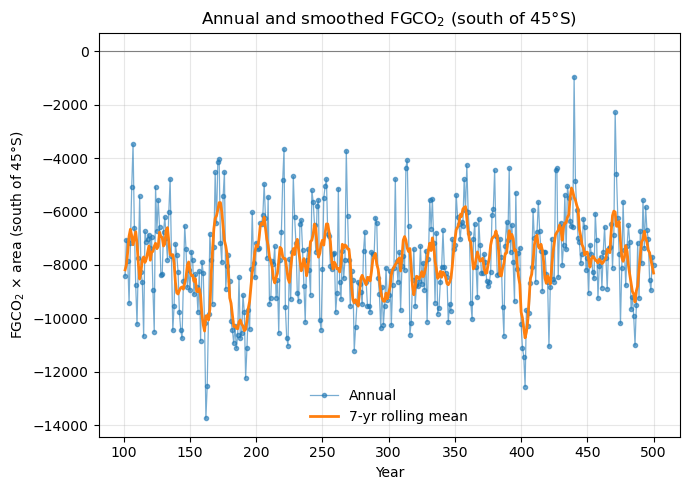

Flip year (zero crossing of smoothed series): None


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --- ensure 1D series on 'year' ---
ts = fgco2_area_sum_by_year

# --- smoothing window (years). Choose 5, 7, 9, 11 depending on how smooth you want it ---
win = 7

# centered rolling mean; min_periods avoids dropping the ends too aggressively
sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

# --- find flip point: first year where smoothed series crosses 0 ---
y = sm.values
yrs = sm["year"].values

valid = np.isfinite(y)
yrs_v = yrs[valid]
y_v = y[valid]

# sign-change indices between consecutive points
sign_change = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]

flip_year = None
if len(sign_change) > 0:
    k = sign_change[0]
    # linear interpolation for a more precise crossing year
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    flip_year = x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ts["year"], ts.values, marker="o", ms=3, lw=0.9, alpha=0.6, label="Annual")
ax.plot(sm["year"], sm.values, lw=2.0, label=f"{win}-yr rolling mean")
ax.axhline(0, color="0.5", lw=0.8)

if flip_year is not None:
    ax.axvline(flip_year, color="k", lw=1.2, ls="--")
    ax.text(
        flip_year, 0.98, f"Flip ~ {flip_year:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top"
    )

ax.set_xlabel("Year")
ax.set_ylabel("FGCO$_2$ × area (south of 45°S)")
ax.set_title("Annual and smoothed FGCO$_2$ (south of 45°S)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Flip year (zero crossing of smoothed series):", flip_year)


In [89]:
# fgco2_area
fgco2_area_sum_by_year_265_275 = (
    fgco2_area
    .where(fgco2_area.latitude < -45)
    .where(density >= 1026.0)
    # .where(density < 1027.5)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .sum(dim=["i", "j"])        
    .compute()
)

In [65]:
# fgco2_area_sum_by_year_260 = (
#     fgco2_area
#     .where(fgco2_area.latitude < -45)
#     .where(density < 1026.5)
#     .where(density > 1026.0)
#     .groupby("time.year")
#     .mean("time")                # 对每年的 time 平均
#     .sum(dim=["i", "j"])        
#     .compute()
# )

In [70]:
# fgco2_annual = fgco2.groupby("time.year").mean('time')

# fgco2_annual_std = fgco2_annual.std(dim = 'year')

In [71]:
# plot_south_polar_auto(fgco2_annual_std, vmax = 2e-10)
# # .plot()
# # std fgco2.std

In [43]:
# 1) 只取 45°S 以南
fgco2_south45 = fgco2.where(fgco2.latitude < -45)

# 2) 先做 zonal mean（沿经度平均）
# 如果你的经度维度是 i（常见于 curvilinear grid）
fgco2_zonal = fgco2_south45.mean(dim="i")

# 原始二维纬度
lat2d = fgco2_south45.latitude

# 沿经度方向（i）取平均，得到 1D 纬度 (j)
lat1d = lat2d.mean(dim="i")

# 重新赋回给 zonal-mean 结果
fgco2_zonal = fgco2_zonal.assign_coords(latitude=lat1d)

# 3) 按年平均
fgco2_zonal_mean_by_year = (
    fgco2_zonal
    .groupby("time.year")
    .mean("time")
)

# fgco2_zonal_mean_by_year


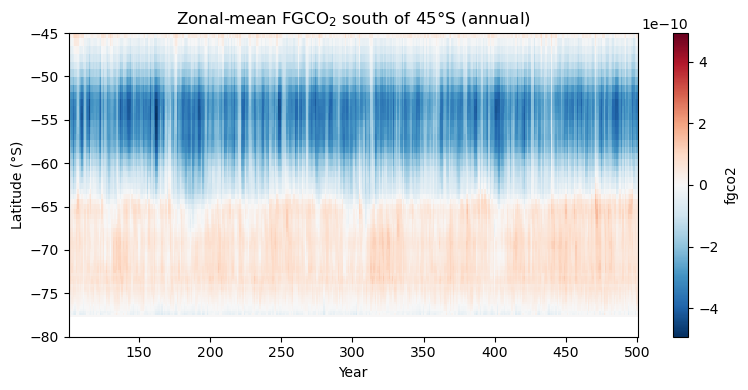

In [44]:
plt.figure(figsize=(8, 4))
fgco2_zonal_mean_by_year.plot(
    x="year",
    y="latitude",
    # cmap="cmocean.balance",
    add_colorbar=True
)

plt.title("Zonal-mean FGCO$_2$ south of 45°S (annual)")
plt.xlabel("Year")
plt.ylabel("Latitude (°S)")

# 只显示 45°S 到南极
plt.ylim(-80, -45)

# 如果纬度是从北到南递增，可强制翻转
# plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


In [72]:
tos_dec = decadal_block_monthly_mean(tos).compute()
sos_dec = decadal_block_monthly_mean(sos).compute()
hfds_dec = decadal_block_monthly_mean(hfds).compute()
wfo_dec = decadal_block_monthly_mean(wfo).compute()



In [73]:
density_dec = gsw.rho(sos_dec, tos_dec, 0)


In [74]:
data_dict={}
data_dict[model]={}
data_dict[model]['density_monthly'] = density_dec
data_dict[model]['tos_monthly'] = tos_dec
data_dict[model]['sos_monthly'] = sos_dec
data_dict[model]['hfds_area_monthly'] = hfds_dec * areacello
data_dict[model]['wfo_area_monthly'] = wfo_dec * areacello


In [77]:
wmt_hfds_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="hfds_area_monthly", v_type="heat") #, block_years=10)
wmt_wfo_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="wfo_area_monthly", v_type="water") #, block_years=10)

# wmt_block: dims ('block','density')

In [78]:
wmt_total_block = wmt_hfds_block + wmt_wfo_block
wmt_total_block = smooth_along_density(wmt_total_block,  win=5)

In [79]:
wmf_total_block = tr_to_fr(wmt_total_block)
# wmf_total_block = smooth_along_density(wmf_total_block,  win=5)


In [80]:
destruction_by_block = -wmf_total_block.where(wmt_total_block.density > 1026.4).where(wmt_total_block.density < 1027.5).sum(dim = 'density')

In [81]:
wmt_total_block_sift = wmt_total_block.where(wmt_total_block.density > 1026.2)
destruction_by_block_2= wmt_total_block_sift.max(dim = "density") - wmt_total_block_sift.min(dim = "density")


In [90]:
block = ((fgco2_area_sum_by_year["year"] - fgco2_area_sum_by_year["year"].min()) // 10).astype("int32")

fgco2_area_sum_by_block = (
    fgco2_area_sum_by_year.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

# block = ((fgco2_area_sum_by_year_265_275["year"] - fgco2_area_sum_by_year_265_275["year"].min()) // 10).astype("int32")

# fgco2_area_sum_by_block = (
#     fgco2_area_sum_by_year_265_275.assign_coords(block=("year", block.data))
#       .groupby("block")
#       .mean("year")
# )

In [ ]:
# fgco2_area_sum_by_block

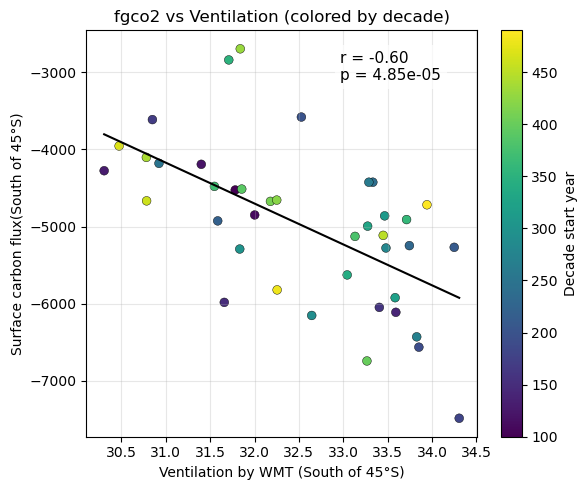

In [91]:
from scipy.stats import pearsonr, linregress
import numpy as np

# 对齐
dissic_y, ventilation_y = xr.align(
    fgco2_area_sum_by_block,
    destruction_by_block_2,
    join="inner"
)

years = dissic_y["block"].values * 10 + 100

# 计算相关（去掉 NaN）
x = ventilation_y.values
y = dissic_y.values
mask = np.isfinite(x) & np.isfinite(y)

r, p = pearsonr(x[mask], y[mask])

# 线性回归
slope, intercept, _, _, _ = linregress(x[mask], y[mask])
xx = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 100)
yy = slope * xx + intercept

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    x, y,
    c=years,
    cmap="viridis",
    s=40,
    edgecolor="k",
    linewidth=0.3
)

# 回归线
plt.plot(xx, yy, color="k", lw=1.5, zorder=3)

plt.xlabel("Ventilation by WMT (South of 45°S)")
# plt.ylabel("Surface DIC (South of 45°S, decadal mean)")
plt.ylabel("Surface carbon flux(South of 45°S)")
plt.title("fgco2 vs Ventilation (colored by decade)")

# 在图中标注相关系数
plt.text(
    0.65, 0.95,
    f"r = {r:.2f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

cbar = plt.colorbar(sc)
cbar.set_label("Decade start year")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


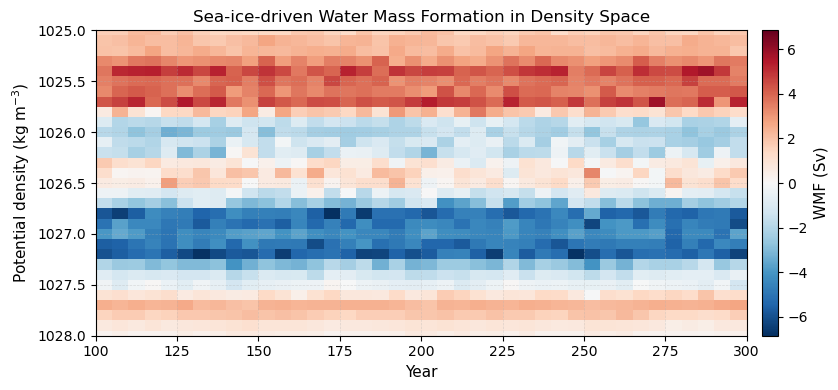

In [403]:
import matplotlib.pyplot as plt

block_years = 5
start_year = 100

years = start_year + (wmf_total_block["block"] + 0.5) * block_years

# assign "year" as a coordinate along "block"
da = wmf_total_block.assign_coords(year=("block", years.data))

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(9, 4))

im = da.plot(
    ax=ax,
    x="year",
    y="density",
    shading="auto",
    add_colorbar=False,
)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"WMF (Sv)")

ax.set_title("Sea-ice-driven Water Mass Formation in Density Space")
ax.set_xlabel("Year")  # <-- since x="year"
ax.set_ylabel(r"Potential density (kg m$^{-3}$)")

ax.set_ylim(1028, 1025)  # cleaner than set_ylim + invert_yaxis
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

fig.tight_layout()
plt.show()


### 7.2 Other models


## Other model

In [87]:
model_list

['ACCESS-ESM1-5',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CNRM-ESM2-1',
 'IPSL-CM6A-LR',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-MM',
 'UKESM1-0-LL']

In [88]:
300# zt_fsitherm_pi.models_best()

300

In [89]:
model = 'CESM2'

In [90]:
# time_range = slice('1850', '2149')
time_range = slice('1200', '1499')

# time_range = slice('0001', '0300')


In [91]:
# fgco2 = zt_fgco2_pi.open_model(model)['fgco2']
# fgco2

In [92]:
# .isel(time=slice(0,300))

In [93]:
# fgco2 = zt_fgco2_pi.open_model(model)['fgco2'].sel(time = time_range)
# tos = zt_tos_pi.open_model(model)['tos'].sel(time = time_range)
# sos = zt_sos_pi.open_model(model)['sos'].sel(time = time_range)
# # dissic = zt_dissic_pi_fs38.open_model(model)['dissic']
# if 'CESM' in model:
#     wfo = zt_vsf_pi.open_model(model)['vsf'].sel(time = time_range)
# else:
#     wfo = zt_wfo_pi.open_model(model)['wfo'].sel(time = time_range)
# hfds = zt_hfds_pi.open_model(model)['hfds'].sel(time = time_range)
# density = gsw.rho(sos, tos, 0).compute()
# # areacello = xr.open_dataset(path)['areacello']


In [94]:
# fgco2

In [95]:
end_num = 3600
fgco2 = zt_fgco2_pi.open_model(model)['fgco2'].isel(time=slice(0,end_num))
tos = zt_tos_pi.open_model(model)['tos'].isel(time=slice(0,end_num))
sos = zt_sos_pi.open_model(model)['sos'].isel(time=slice(0,end_num))
# dissic = zt_dissic_pi_fs38.open_model(model)['dissic']
if 'CESM' in model:
    wfo = zt_vsf_pi.open_model(model)['vsf'].isel(time=slice(0,end_num))
else:
    wfo = zt_wfo_pi.open_model(model)['wfo'].isel(time=slice(0,end_num))
hfds = zt_hfds_pi.open_model(model)['hfds'].isel(time=slice(0,end_num))
density = gsw.rho(sos, tos, 0).compute()
# areacello = xr.open_dataset(path)['areacello']


In [96]:
fn = f"/g/data/jk72/zc0441/Subject_2/data/{model}/areacello_historical_gn.nc"
areacello = xr.open_dataset(fn)["areacello"]

In [97]:
# zt_fgco2_pi.open_model(model)#['fgco2']
# areacello
lat_coord, lon_coord = get_lat_lon_coords(fgco2)
j_dim, i_dim = get_i_j_dim(fgco2)



In [98]:
# i_dim

In [99]:
# areacello
fgco2_area =  fgco2 * areacello
fgco2_area = fgco2_area.assign_coords(
    latitude=fgco2[lat_coord],
    longitude=fgco2[lon_coord]
)

In [100]:

fgco2_area_sum_by_year = (
    fgco2_area
    .where(fgco2_area[lat_coord] < -45)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .sum(dim=[i_dim, j_dim])        
    .compute()
)

In [101]:
tos_dec = decadal_block_monthly_mean(tos).compute()
sos_dec = decadal_block_monthly_mean(sos).compute()
hfds_dec = decadal_block_monthly_mean(hfds).compute()
wfo_dec = decadal_block_monthly_mean(wfo).compute()



In [102]:
density_dec = gsw.rho(sos_dec, tos_dec, 0)


In [103]:
# density_dec

In [104]:
data_dict={}
data_dict[model]={}
data_dict[model]['density_monthly'] = density_dec
data_dict[model]['tos_monthly'] = tos_dec
data_dict[model]['sos_monthly'] = sos_dec
data_dict[model]['hfds_area_monthly'] = hfds_dec * areacello
data_dict[model]['wfo_area_monthly'] = wfo_dec * areacello


In [105]:
wmt_hfds_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="hfds_area_monthly", v_type="heat") #, block_years=10)
# wmt_wfo_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="wfo_area_monthly", v_type="water") #, block_years=10)
wmt_wfo_block = -calculate_wmt_from_blocked(data_dict, model, variable_name="wfo_area_monthly", v_type="water") #, block_years=10)


# wmt_block: dims ('block','density')

In [106]:
if "IPSL" in model:
    wmt_wfo_block = - wmt_wfo_block

In [107]:
wmt_total_block = wmt_hfds_block + wmt_wfo_block
wmt_total_block = smooth_along_density(wmt_total_block,  win=5)

In [108]:
max_idx = wmt_total_block.mean('block').idxmax()
min_idx = wmt_total_block.mean('block').idxmin()


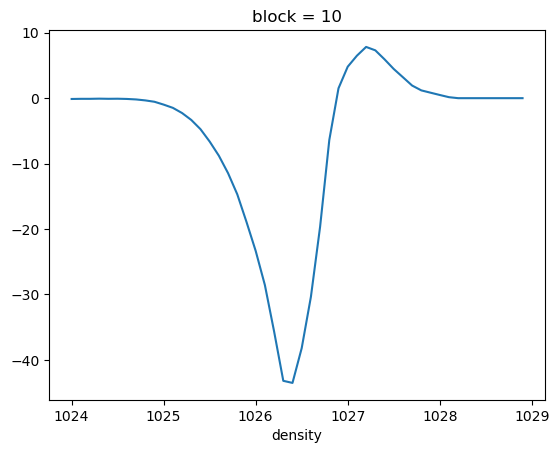

In [109]:
wmt_total_block[10,:].plot()

In [110]:
# wmt_wfo_block[0, : ].plot()

In [111]:
wmf_total_block = tr_to_fr(wmt_total_block)


In [112]:
wmt_total_block_sift = wmt_total_block.where(wmt_total_block.density > 1026.2)
destruction_by_block_2= wmt_total_block_sift.max(dim = "density") - wmt_total_block_sift.min(dim = "density")


In [113]:
block = ((fgco2_area_sum_by_year["year"] - fgco2_area_sum_by_year["year"].min()) // 10).astype("int32")

fgco2_area_sum_by_block = (
    fgco2_area_sum_by_year.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

In [128]:
# fgco2_area
fgco2_area_sum_by_year_band = (
    fgco2_area
    .where(fgco2_area[lat_coord] < -30)
    .where(density >= min_idx)
    # .where(density < max_idx)
    .groupby("time.year")
    .mean("time")                # 对每年的 time 平均
    .sum(dim=[i_dim, j_dim])        
    .compute()
)

fgco2_area_sum_by_block_band = (
    fgco2_area_sum_by_year_band.assign_coords(block=("year", block.data))
      .groupby("block")
      .mean("year")
)

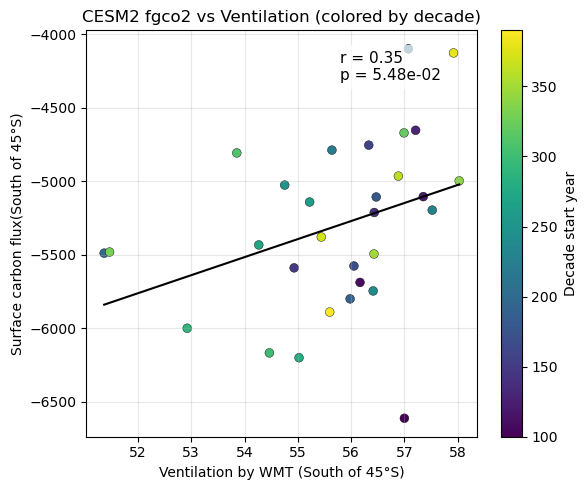

In [129]:
from scipy.stats import pearsonr, linregress
import numpy as np

# 对齐
dissic_y, ventilation_y = xr.align(
    fgco2_area_sum_by_block_band,
    destruction_by_block_2,
    join="inner"
)

years = dissic_y["block"].values * 10 + 100

# 计算相关（去掉 NaN）
x = ventilation_y.values
y = dissic_y.values
mask = np.isfinite(x) & np.isfinite(y)

r, p = pearsonr(x[mask], y[mask])

# 线性回归
slope, intercept, _, _, _ = linregress(x[mask], y[mask])
xx = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 100)
yy = slope * xx + intercept

plt.figure(figsize=(6, 5))
sc = plt.scatter(
    x, y,
    c=years,
    cmap="viridis",
    s=40,
    edgecolor="k",
    linewidth=0.3
)

# 回归线
plt.plot(xx, yy, color="k", lw=1.5, zorder=3)

plt.xlabel("Ventilation by WMT (South of 45°S)")
# plt.ylabel("Surface DIC (South of 45°S, decadal mean)")
plt.ylabel("Surface carbon flux(South of 45°S)")
plt.title(f"{model} fgco2 vs Ventilation (colored by decade)")

# 在图中标注相关系数
plt.text(
    0.65, 0.95,
    f"r = {r:.2f}\np = {p:.2e}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

cbar = plt.colorbar(sc)
cbar.set_label("Decade start year")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


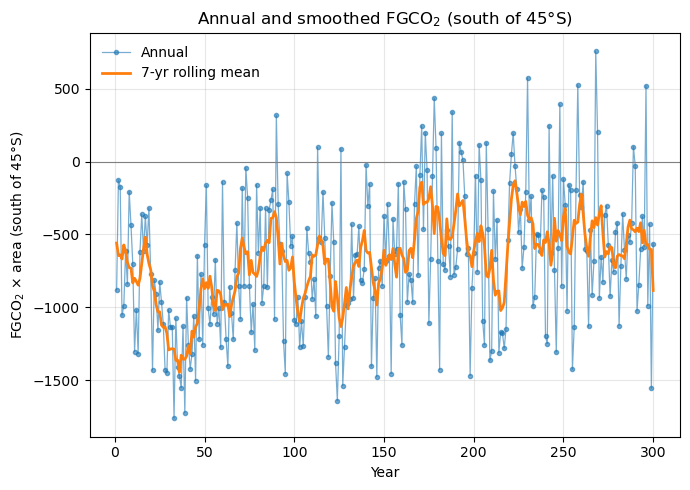

Flip year (zero crossing of smoothed series): None


In [131]:
import numpy as np
import matplotlib.pyplot as plt

# --- ensure 1D series on 'year' ---
ts = fgco2_area_sum_by_year
ts = fgco2_area_sum_by_year-fgco2_area_sum_by_year_band


# --- smoothing window (years). Choose 5, 7, 9, 11 depending on how smooth you want it ---
win = 7

# centered rolling mean; min_periods avoids dropping the ends too aggressively
sm = ts.rolling(year=win, center=True, min_periods=max(3, win//2)).mean()

# --- find flip point: first year where smoothed series crosses 0 ---
y = sm.values
yrs = sm["year"].values

valid = np.isfinite(y)
yrs_v = yrs[valid]
y_v = y[valid]

# sign-change indices between consecutive points
sign_change = np.where(np.sign(y_v[:-1]) * np.sign(y_v[1:]) < 0)[0]

flip_year = None
if len(sign_change) > 0:
    k = sign_change[0]
    # linear interpolation for a more precise crossing year
    y0, y1 = y_v[k], y_v[k+1]
    x0, x1 = yrs_v[k], yrs_v[k+1]
    flip_year = x0 + (0 - y0) * (x1 - x0) / (y1 - y0)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ts["year"], ts.values, marker="o", ms=3, lw=0.9, alpha=0.6, label="Annual")
ax.plot(sm["year"], sm.values, lw=2.0, label=f"{win}-yr rolling mean")
ax.axhline(0, color="0.5", lw=0.8)

if flip_year is not None:
    ax.axvline(flip_year, color="k", lw=1.2, ls="--")
    ax.text(
        flip_year, 0.98, f"Flip ~ {flip_year:.1f}",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top"
    )

ax.set_xlabel("Year")
ax.set_ylabel("FGCO$_2$ × area (south of 45°S)")
ax.set_title("Annual and smoothed FGCO$_2$ (south of 45°S)")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Flip year (zero crossing of smoothed series):", flip_year)


In [117]:
fgco2_mean = fgco2.mean('time').compute()

In [118]:
density_winter = density_dec.sel(month=[6,7,8]).mean(dim=['block','month']).compute()
density_mean = density_dec.mean(dim=['block','month']).compute()


In [119]:
fgco2_mean.max()
# [min_idx, max_idx]

<xarray.DataArray 'fgco2' ()> Size: 8B
array(1.92999661e-09)

In [120]:
# fgco2_mean.plot()

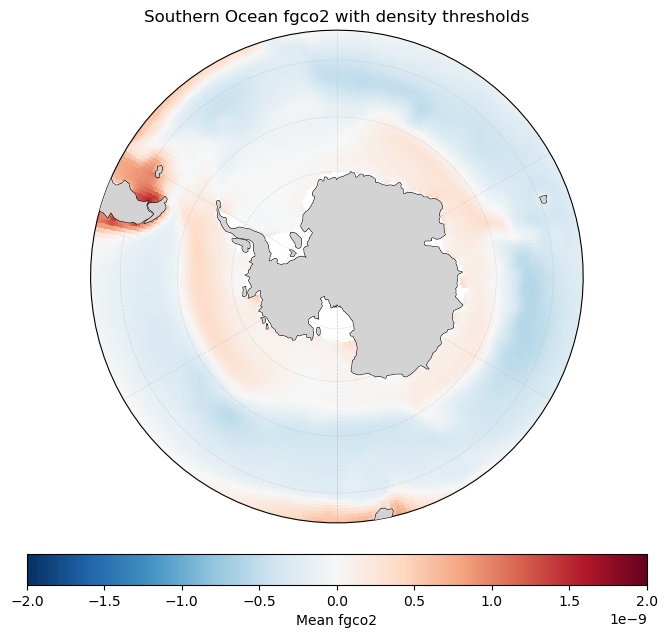

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lat_name, lon_name = get_lat_lon_coords(fgco2_mean)

lat = fgco2_mean[lat_name]
lon = fgco2_mean[lon_name]

proj = ccrs.SouthPolarStereo()
pc = ccrs.PlateCarree()

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

ax.set_extent([-180,180,-90,-45], crs=pc)

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.coastlines(linewidth=0.8)

ax.gridlines(crs=pc, linewidth=0.5, linestyle="--", alpha=0.4)

# ---- fgco2 pcolormesh ----
mesh = ax.pcolormesh(
    lon,
    lat,
    fgco2_mean,
    transform=pc,
    cmap="RdBu_r",
    vmin=-2e-9,
    vmax=2e-9,
    shading="auto",
    zorder=1
)

# ---- density contours ----
# cs = ax.contour(
#     lon,
#     lat,
#     density_winter,
#     levels=[min_idx, max_idx],
#     colors="k",
#     linewidths=1.8,
#     transform=pc,
#     zorder=4
# )

# ax.clabel(cs, fmt="%.2f", fontsize=9)

# colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("Mean fgco2")

ax.set_title("Southern Ocean fgco2 with density thresholds")

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax.set_boundary(circle, transform=ax.transAxes)
plt.show()

In [122]:
# fgco2_mean.plot()


In [127]:
# density_winter.plot()

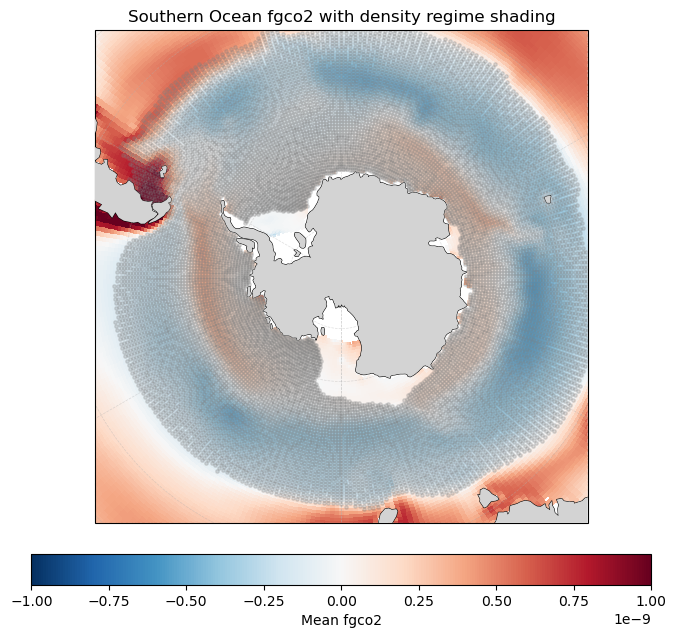

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lat_name, lon_name = get_lat_lon_coords(fgco2_mean)

lat = fgco2_mean[lat_name]
lon = fgco2_mean[lon_name]

proj = ccrs.SouthPolarStereo()
pc = ccrs.PlateCarree()

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

ax.set_extent([-180,180,-90,-45], crs=pc)

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=4)
ax.coastlines(linewidth=0.8)

ax.gridlines(crs=pc, linewidth=0.5, linestyle="--", alpha=0.4)

# -------- fgco2 background --------
mesh = ax.pcolormesh(
    lon,
    lat,
    fgco2_mean,
    transform=pc,
    cmap="RdBu_r",
    vmin=-1e-9,
    vmax=1e-9,
    # shading="auto",
    zorder=1
)

# -------- density band shading --------
mask = (density_winter >= min_idx) & (density_winter<= max_idx)
# mask = (density_mean >= min_idx) & (density_mean<= max_idx)


ax.scatter(
    lon.where(mask),
    lat.where(mask),
    s=6,                # 点大小，可调
    color="grey",       # 单一颜色
    alpha=0.25,
    transform=pc,
    zorder=2
)
# colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("Mean fgco2")

ax.set_title("Southern Ocean fgco2 with density regime shading")

plt.show()